<center><font size=6> Bank Churn Prediction </font></center>

## Problem Statement

### Context

Businesses like banks which provide service have to worry about problem of 'Customer Churn' i.e. customers leaving and joining another service provider. It is important to understand which aspects of the service influence a customer's decision in this regard. Management can concentrate efforts on improvement of service, keeping in mind these priorities.

### Objective

You as a Data scientist with the  bank need to  build a neural network based classifier that can determine whether a customer will leave the bank  or not in the next 6 months.

### Data Dictionary

* CustomerId: Unique ID which is assigned to each customer

* Surname: Last name of the customer

* CreditScore: It defines the credit history of the customer.
  
* Geography: A customer’s location
   
* Gender: It defines the Gender of the customer
   
* Age: Age of the customer
    
* Tenure: Number of years for which the customer has been with the bank

* NumOfProducts: refers to the number of products that a customer has purchased through the bank.

* Balance: Account balance

* HasCrCard: It is a categorical variable which decides whether the customer has credit card or not.

* EstimatedSalary: Estimated salary

* isActiveMember: Is is a categorical variable which decides whether the customer is active member of the bank or not ( Active member in the sense, using bank products regularly, making transactions etc )

* Exited : whether or not the customer left the bank within six month. It can take two values
** 0=No ( Customer did not leave the bank )
** 1=Yes ( Customer left the bank )

**Importing the necessary libraries**

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# library to import to standardize the data
from sklearn.preprocessing import StandardScaler, LabelEncoder

# importing different functions to build models
import tensorflow as tf
from tensorflow import keras
from keras import backend
from keras.models import Sequential
from keras.layers import Dense, Dropout

# importing SMOTE
from imblearn.over_sampling import SMOTE

# importing metrics
from sklearn.metrics import confusion_matrix,roc_curve,classification_report,recall_score

import random

# Library to avoid the warnings
import warnings
warnings.filterwarnings("ignore")

## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
ds=pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DeepLearning/Bank_Churn.csv')

## Data Overview

In [ ]:
# View the first 5 rows of the data
ds.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
# View the last 5 rows of the data
ds.tail()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,France,Female,28,4,130142.79,1,1,0,38190.78,0


In [ ]:
# Understand the Shape of the data
ds.shape

(10000, 14)

In [ ]:
# Check the data types of the columns for the dataset
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
# Check the Statistical Summary of the data
ds.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
# Check for Missing Values
ds.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
# Check for duplicate values
ds.duplicated().sum()

np.int64(0)

In [ ]:
# Check for unique values of each column
ds.nunique()

,0
RowNumber,10000
CustomerId,10000
Surname,2932
CreditScore,460
Geography,3
Gender,2
Age,70
Tenure,11
Balance,6382
NumOfProducts,4


In [ ]:
# Dropping RowNumber, CustomerId as they are unique.
# Dropping Surname as this doesn't provide information about the customer's characteristics that would help predict churn.
ds.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

## Exploratory Data Analysis

### Univariate Analysis

In [ ]:
# function to plot a boxplot and a histogram along the same scale.

def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on CreditScore

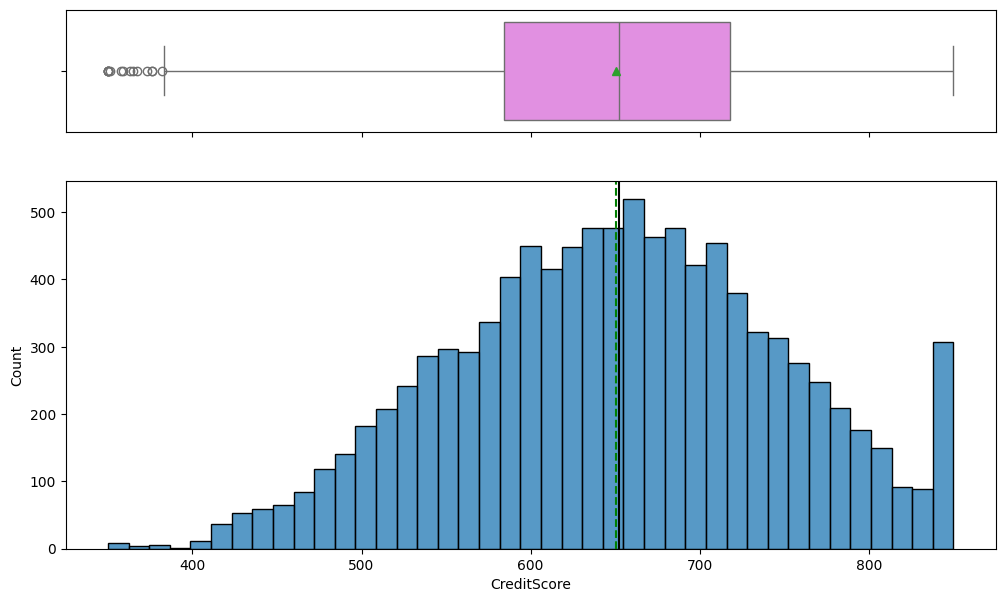

In [ ]:
histogram_boxplot(ds,'CreditScore')

1) Average: 650.53, normal distribution with outliers below 400 score. This could indicate riskier customers with exceptionally low credit scores.

#### Observations on Age

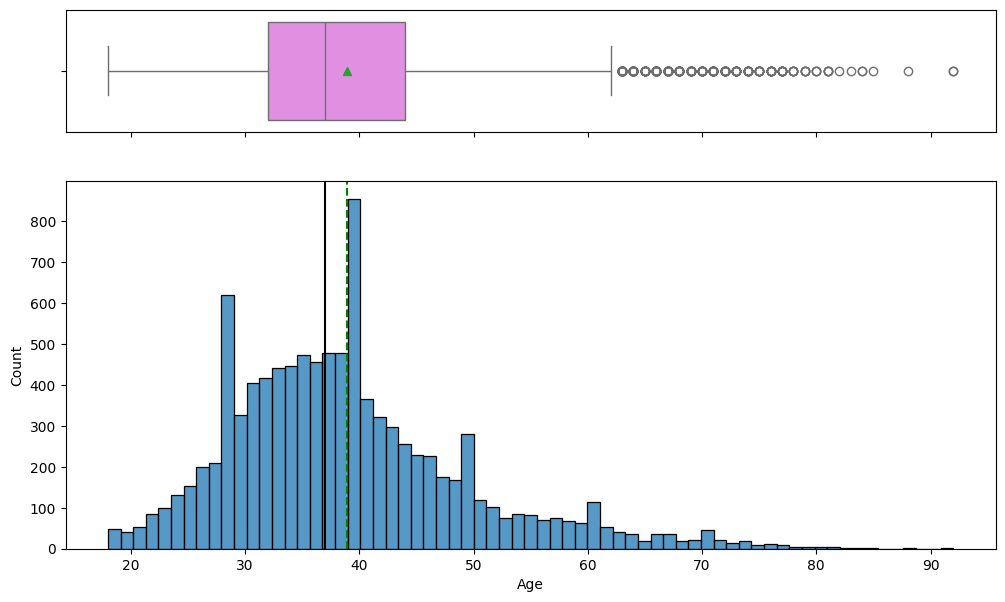

In [ ]:
histogram_boxplot(ds,'Age')

1) The box plot shows a concentration of ages around mid-30s to early 40s.

2) Outliers exist, indicating some older customers who might have different banking behaviors.


#### Observations on Balance

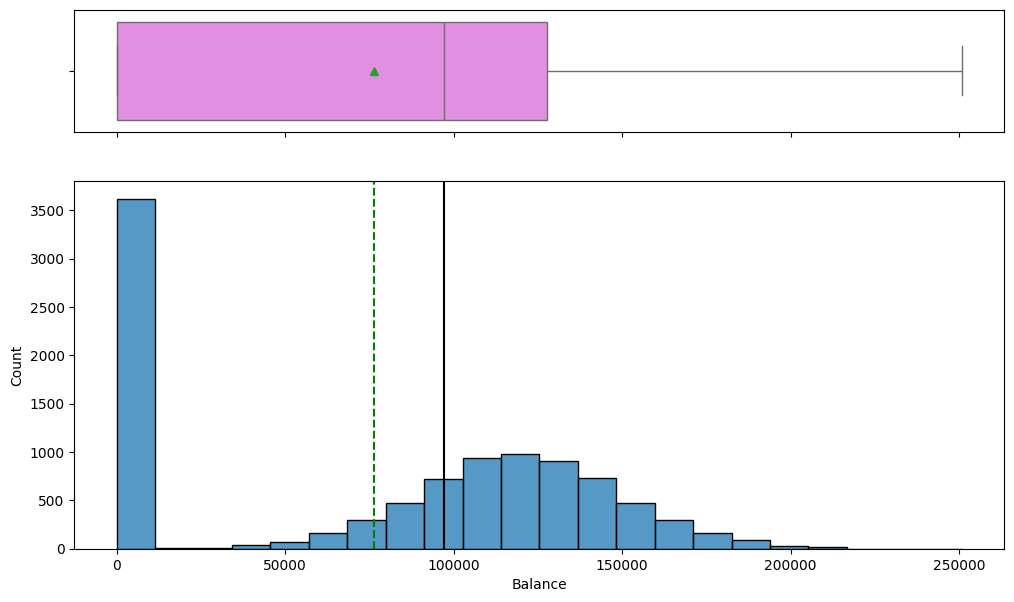

In [ ]:
histogram_boxplot(ds,'Balance')

1) The high number of zero balances suggests that a significant portion of customers might not use their accounts actively.

2) Customers with higher balances may have different banking behaviors, possibly less engaged with traditional banking products.

3) Mean is ~76K and Median is ~97k, high variation with notable zero balances.


####Observations on Estimated Salary

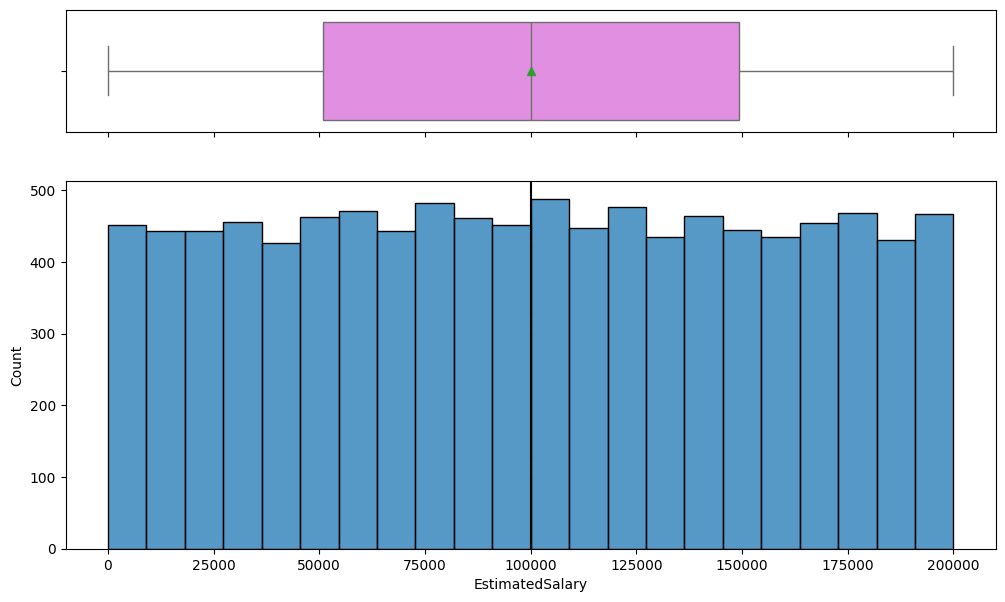

In [ ]:
histogram_boxplot(ds,'EstimatedSalary')

1) The box plot shows that estimated salaries are evenly distributed, with no significant outliers.

2) The interquartile range (IQR) suggests a balanced spread of salaries, meaning customers likely fall across multiple income brackets.

3) The median salary (green triangle) appears to be centrally positioned, reinforcing the uniformity in distribution.

4) Since salary is uniformly distributed, it might not be a strong predictor of churn on its own.

#### Observations on Geography

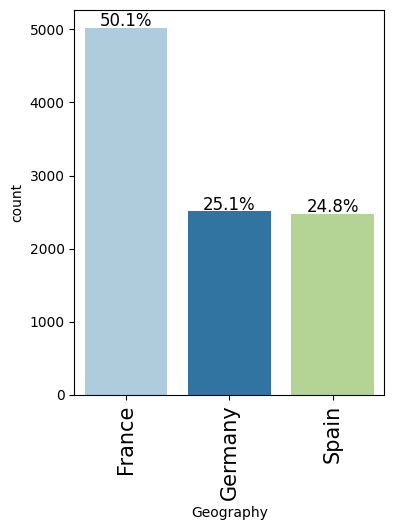

In [ ]:
labeled_barplot(ds,'Geography',perc=True)

1) Most customers are from France (50.1%) followed by Germany and Spain.

#### Observations on Gender

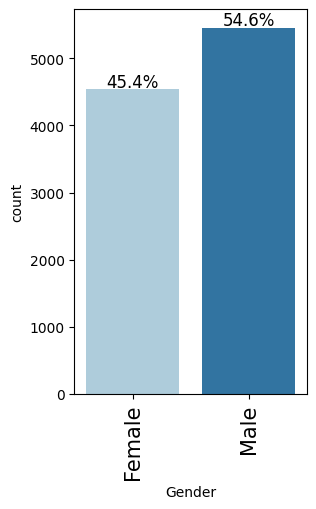

In [ ]:
labeled_barplot(ds,'Gender', perc=True)

1) The gender ratio is close to balanced but slightly favors males.

#### Observations on Tenure

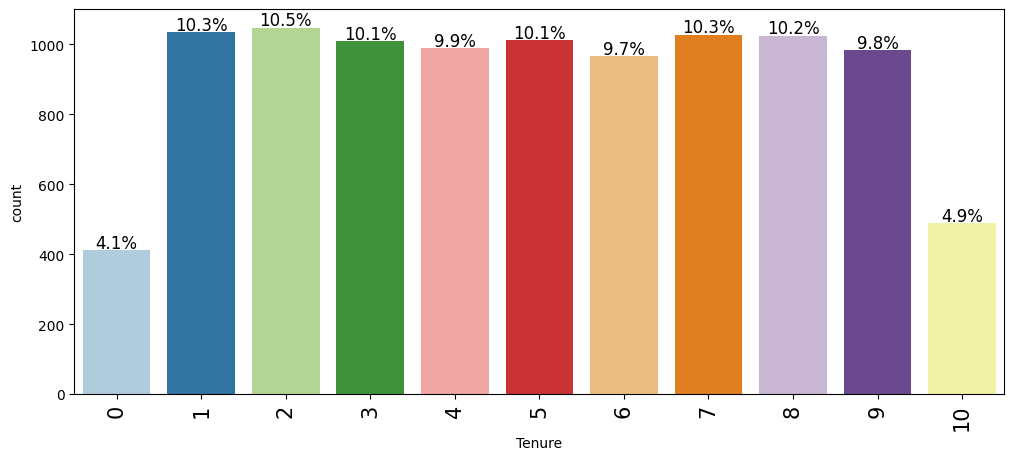

In [ ]:
labeled_barplot(ds,'Tenure', perc=True)

1) Customers tend to leave or remain within the bank around the 2-5 year mark, suggesting it could be an important retention phase.

2) Understanding customer needs during tenure peaks (1-9 years) may help in customer engagement strategies.


#### Observations on Number of Products

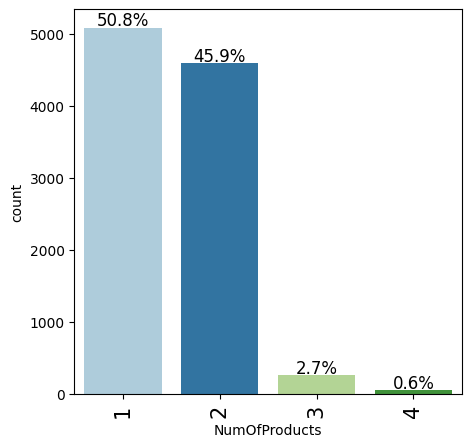

In [ ]:
labeled_barplot(ds,'NumOfProducts', perc=True)

1) High concentration in 1 or 2 products suggests that most customers do not diversify their banking services.

2) The low percentage of customers with 3+ products might indicate limited engagement with premium services.


#### Observations on Has Credit Card

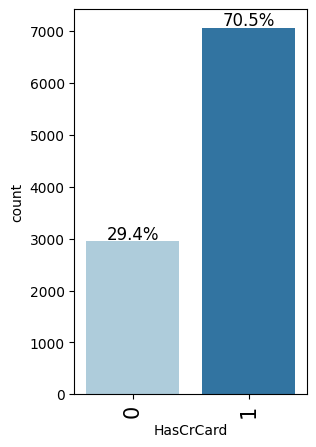

In [ ]:
labeled_barplot(ds,'HasCrCard', perc=True)

1) 71% of the customers possess credit card while 29.4% do not.

2) Since most customers have a credit card, credit-related services may be a key factor in customer engagement.

3) Non-credit-card holders represent a potential market for upselling financial products.


#### Observations on Is Active Member

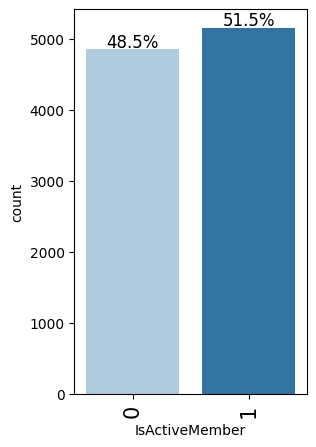

In [ ]:
labeled_barplot(ds,'IsActiveMember', perc=True)

1) Active members just barely outnumber inactive ones, customer engagement strategies may need improvement.

2) If inactive members correlate with higher churn, the bank might need to target them with personalized offers.

#### Observations on Exited

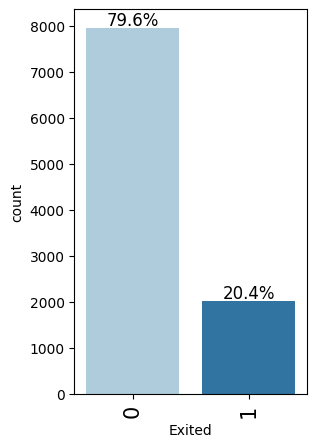

In [ ]:
labeled_barplot(ds,'Exited', perc=True)

1) Since only 20.4% of customers churned, the dataset is imbalanced, meaning the model may favor predicting "non-churn" cases.

2) Identifying patterns among churned customers (1) could help improve retention strategies.


### Bivariate Analysis

In [ ]:
# function to plot stacked bar chart


def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

#### Correlation Plot

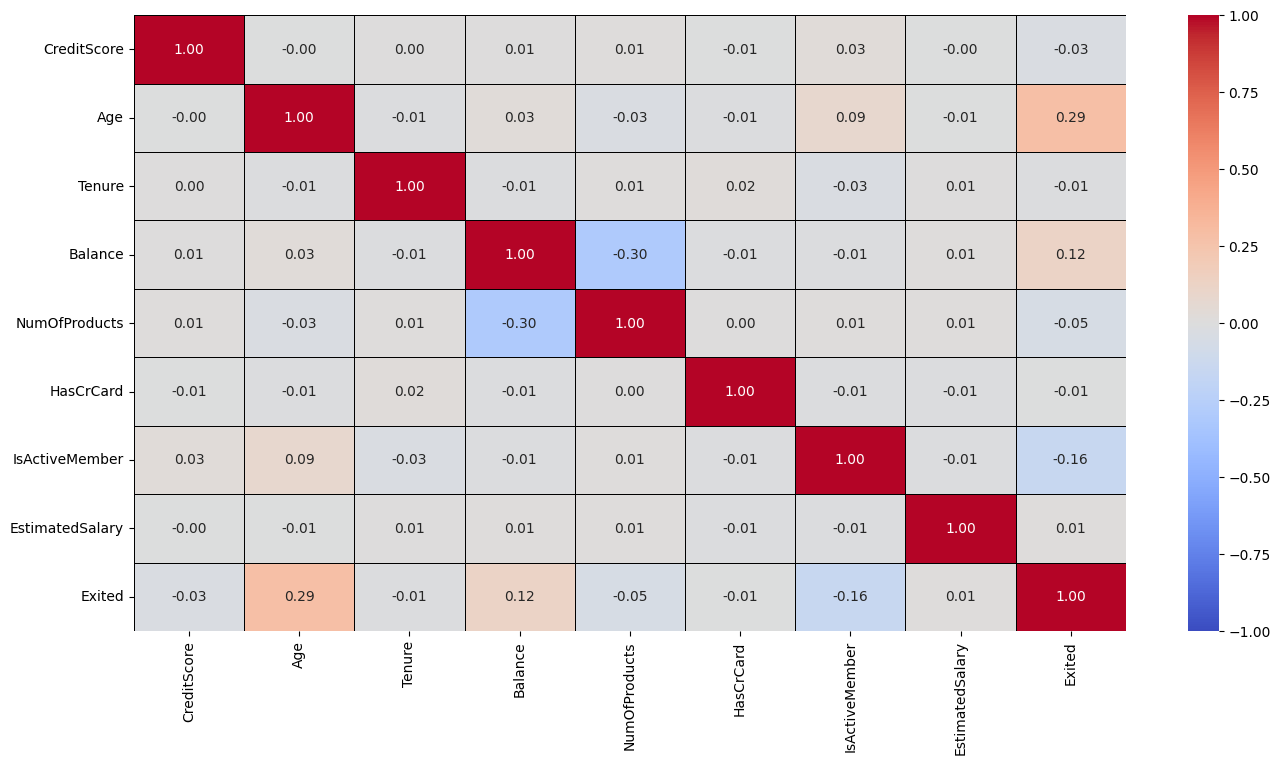

In [ ]:
# Selecting only numerical columns
cols_list = ds.select_dtypes(include=np.number).columns.tolist()

# Set up the plot dimensions
plt.figure(figsize=(16, 8))

# Generate a heatmap for the correlation matrix with customized visuals
sns.heatmap(ds[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="coolwarm", linewidths=0.5, linecolor='black')

# Display the heatmap
plt.show()

**Age and Exited Relationship:** There is a modest positive correlation between 'Age' and 'Exited', suggesting that older customers are slightly more likely to leave the bank.

**Weak Correlation Other variables** show weak or negligible correlations with each other, indicating no strong linear relationships that could directly influence customer behaviors or decisions within this dataset.

#### Exited Vs Geography

Exited        0     1    All
Geography                   
All        7963  2037  10000
Germany    1695   814   2509
France     4204   810   5014
Spain      2064   413   2477
------------------------------------------------------------------------------------------------------------------------


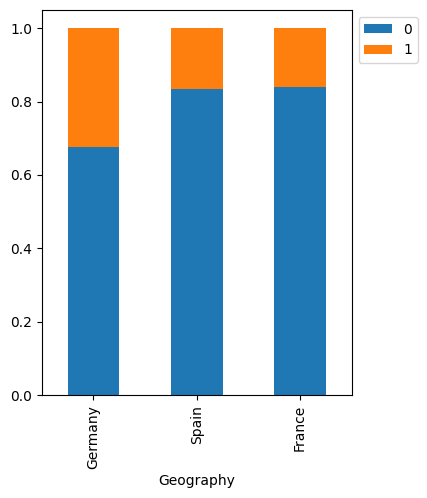

In [ ]:
stacked_barplot(ds, "Geography", "Exited" )

1) **Overall Churn Rate:** As noted previously, 2,037 out of 10,000 customers have exited.

**2) Customers from Germany:**
There are 2,509 customers from Germany.
Out of these, 814 have exited and 1695 have stayed.
The churn rate for customers from Germany is approximately (814 / 2509) * 100 ≈ 32.4%.

3) **Customers from France:**
There are 5,014 customers from France.
Out of these, 810 have exited and 4204 have stayed.
The churn rate for customers from France is approximately (810 / 5014) * 100 ≈ 16.2%.

3) **Customers from Spain:**
There are 2,477 customers from Spain.
Out of these, 413 have exited and 2064 have stayed.
The churn rate for customers from Spain is approximately (413 / 2477) * 100 ≈ 16.7%.

**Conclusion:** Customers from Germany have a significantly higher churn rate (around 32.4%) compared to customers from France (around 16.2%) and Spain (around 16.7%). This suggests that geographic location, particularly being in Germany, is a notable factor influencing customer churn.

#### Exited Vs Gender

Exited     0     1    All
Gender                   
All     7963  2037  10000
Female  3404  1139   4543
Male    4559   898   5457
------------------------------------------------------------------------------------------------------------------------


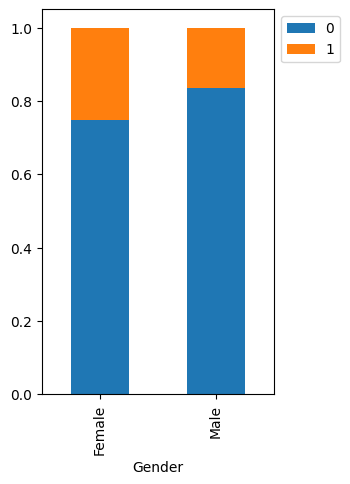

In [ ]:
stacked_barplot(ds, "Gender", "Exited" )

1) **Overall Churn Rate:** Out of 10,000 customers, 2,037 have exited the bank (churned), while 7,963 have stayed.

2) **Among female customers** (4,543 total), 1,139 have left the bank, which is 25.1% of female customers.

3) **Among male customers** (5,457 total), 898 have exited, which is 16.5% of male customers.

**Conclusion:** Female customers have a higher churn rate (25.1%) compared to male customers (16.5%), suggesting they may be more likely to leave the bank.


#### Exited Vs Number of Products

Exited            0     1    All
NumOfProducts                   
All            7963  2037  10000
1              3675  1409   5084
2              4242   348   4590
3                46   220    266
4                 0    60     60
------------------------------------------------------------------------------------------------------------------------


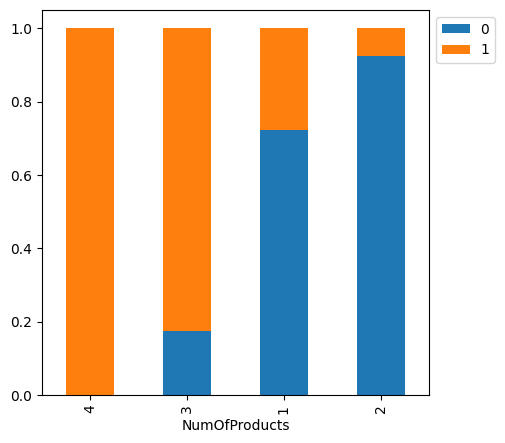

In [ ]:
stacked_barplot(ds, "NumOfProducts", "Exited" )

1) **Overall Churn Rate:** Out of 10,000 customers, 2,037 have exited (churned), while 7,963 have stayed.

2) **Customers with 1 or 2 Products:** The vast majority of customers (5084 + 4590 = 9674 out of 10000) have either 1 or 2 products.

a) Customers with 1 product have a significant number of churns (1409 out of 5084).

b) Customers with 2 products have a much lower number of churns (348 out of 4590).

3) **Customers with 3 or 4 Products:** A smaller number of customers have 3 or 4 products (266 + 60 = 326 out of 10000).

Crucially, customers with 3 or 4 products have a very high propensity to churn. All 60 customers with 4 products have exited, and a large proportion of customers with 3 products (220 out of 266) have also exited.

**Conclusion:** Customers with 3 or 4 products are significantly more likely to churn compared to those with 1 or 2 products. This suggests that offering too many products might be a strong indicator of potential churn.

#### Exited Vs Has Credit Card

Exited        0     1    All
HasCrCard                   
All        7963  2037  10000
1          5631  1424   7055
0          2332   613   2945
------------------------------------------------------------------------------------------------------------------------


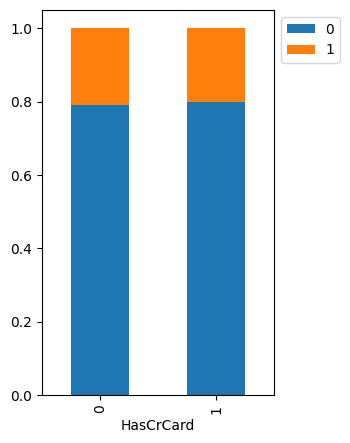

In [ ]:
stacked_barplot(ds, "HasCrCard", "Exited" )

1) **Overall Churn Rate:** As seen above, 2,037 out of 10,000 customers have exited.

2) **Customers with a Credit Card (HasCrCard = 1):**
There are 7,055 customers who have a credit card.
Out of these, 1,424 have exited and 5,631 have stayed.
The churn rate for customers with a credit card is approximately (1424 / 7055) * 100 ≈ 20.2%.

3) **Customers without a Credit Card (HasCrCard = 0):**
There are 2,945 customers who do not have a credit card.
Out of these, 613 have exited and 2,332 have stayed.
The churn rate for customers without a credit card is approximately (613 / 2945) * 100 ≈ 20.8%.

**Conclusion:** There is a very small difference in the churn rate between customers who have a credit card and those who do not. The presence or absence of a credit card does not appear to be a strong indicator of whether a customer will churn. The churn rates are very similar for both groups (around 20-21%).

#### Exited Vs Is Active Member

Exited             0     1    All
IsActiveMember                   
All             7963  2037  10000
0               3547  1302   4849
1               4416   735   5151
------------------------------------------------------------------------------------------------------------------------


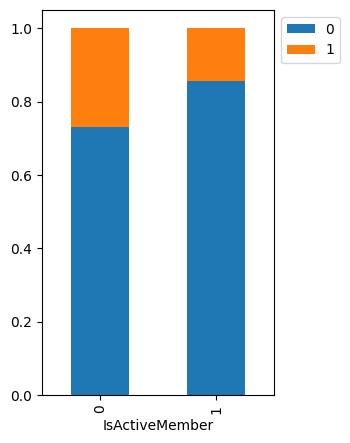

In [ ]:
stacked_barplot(ds, "IsActiveMember", "Exited" )

1) **Overall Churn Rate:** It seems 2,037 out of 10,000 customers have exited.

2) **Customers who are Not Active Members (IsActiveMember = 0):**
There are 4,849 customers who are not active members.
Out of these, 1,302 have exited and 3,547 have stayed.
The churn rate for customers who are not active members is approximately (1302 / 4849) * 100 ≈ 26.8%.

3) **Customers who are Active Members (IsActiveMember = 1):**
There are 5,151 customers who are active members.
Out of these, 735 have exited and 4,416 have stayed.
The churn rate for customers who are active members is approximately (735 / 5151) * 100 ≈ 14.3%.

**Conclusion:** Customers who are not active members have a significantly higher churn rate (26.8%) compared to customers who are active members (14.3%). This suggests that being an active member of the bank is a strong indicator of customer retention.

#### Exited Vs Is Credit Score

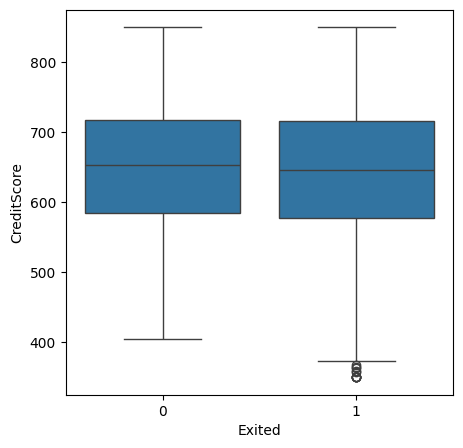

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(y='CreditScore',x='Exited',data=ds)
plt.show()

**Observations:**

1) The median credit score for both groups is around 650, meaning the central tendency of credit scores is similar.

2) The interquartile range (IQR) is approximately 600 to 700 for both groups, showing similar variability.

3) The whiskers extend from about 500 to 800 for non-exited individuals and 400 to 800 for exited individuals, indicating that exited customers have a broader range of credit scores.

4) There are outliers below 400 in the exited group, suggesting that some customers with exceptionally low credit scores are more likely to leave.

**Conclusion:**

1) Credit score alone may not be a strong predictor of churn since both groups have similar distributions.

2) However, customers with very low credit scores (<400) appear more likely to exit, which might indicate financial instability playing a role in churn


#### Exited Vs Is Age

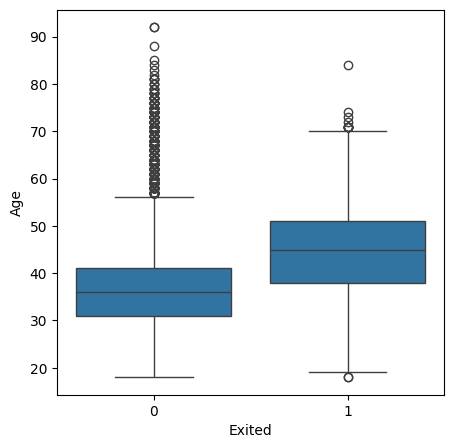

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(y='Age',x='Exited',data=ds)
plt.show()

**Observations:**

1) **Age and Churn Relationship:** The median age of customers who have exited (category 1) is noticeably higher than those who have not exited (category 0). This suggests that older customers may be more prone to churn.

2) **Age Distribution:**

a) The age range for non-exited customers (category 0) is broader, with more outliers, indicating a diverse age group that remains with the bank.

b) Exited customers (category 1) show a more concentrated age range, suggesting churn is more common among specific age brackets.

**Conclusion:**

1) Older customers may have different banking needs, and dissatisfaction with products/services could be a factor in churn.

2) Younger customers seem more likely to stay, possibly due to banking habits, financial needs, or product offerings.



#### Exited Vs Tenure

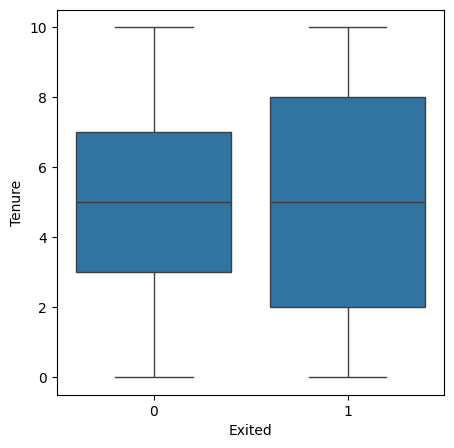

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(y='Tenure',x='Exited',data=ds)
plt.show()

**Observations:**

1) Customers who exited (1) appear to have a slightly higher median tenure compared to those who stayed (0).This suggests that longer-tenured customers may be slightly more prone to leaving the bank.

2) The range of tenure for exited customers is slightly larger compared to non-exited customers. This could indicate that customers across different tenure durations are exiting, making tenure less of a singular determinant.

**Conclusion:**

1) Customers with mid-to-long tenure leaving might suggest dissatisfaction after years of service.

2) New customers may be retained better, possibly due to onboarding benefits or promotions.

#### Exited Vs Balance

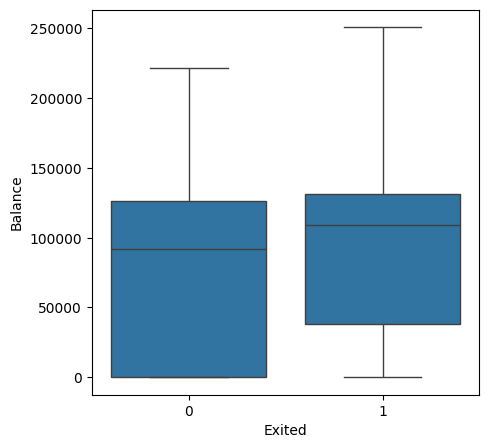

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(y='Balance',x='Exited',data=ds)
plt.show()

**Observations**

1) Customers who exited (1) tend to have a slightly higher median balance (around 125,000).

2) Customers who did not exit (0) have a median balance of around 100,000.This suggests that individuals with higher balances may be slightly more likely to leave the bank.

3) The balance range is quite similar between both groups, spanning approximately 25,000 to 200,000.

4) Whiskers extend from 0 to 250,000, implying that some customers have much higher balances, regardless of churn status.

**Conclusion:**

1) Customers with lower balances might be more engaged with the bank's services and therefore less likely to exit.

2) Those with higher balances exiting could indicate they are seeking better financial products elsewhere or are less dependent on the bank.

#### Exited Vs Estimated Salary

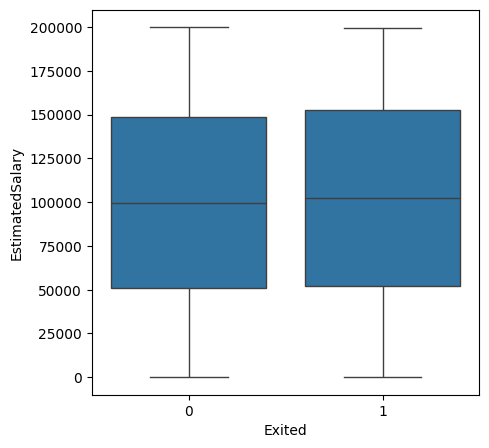

In [ ]:
plt.figure(figsize=(5,5))
sns.boxplot(y='EstimatedSalary',x='Exited',data=ds)
plt.show()

**Observations:**

1) The median estimated salary for both exited (1) and non-exited (0) customers appears similar, around 100,000.

2) The interquartile range (IQR) is also similar, indicating that estimated salary does not show significant differences between churned and retained customers.

3) Both groups have wide salary ranges, from 0 to nearly 200,000.

**Conclusion:**

1) Since estimated salary shows no clear trend in churn behavior, it may not be a strong predictor.

## Data Preprocessing

### Dummy Variable Creation

In [ ]:
# Selecting all the categorical variables and creating dummy features
ds = pd.get_dummies(ds,columns=ds.select_dtypes(include=["object"]).columns.tolist(),drop_first=True)
ds = ds.astype(float)
ds.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619.0,42.0,2.0,0.00,1.0,1.0,1.0,101348.88,1.0,0.0,0.0,0.0
1,608.0,41.0,1.0,83807.86,1.0,0.0,1.0,112542.58,0.0,0.0,1.0,0.0
2,502.0,42.0,8.0,159660.80,3.0,1.0,0.0,113931.57,1.0,0.0,0.0,0.0
3,699.0,39.0,1.0,0.00,2.0,0.0,0.0,93826.63,0.0,0.0,0.0,0.0
4,850.0,43.0,2.0,125510.82,1.0,1.0,1.0,79084.10,0.0,0.0,1.0,0.0


### Train-validation-test Split

In [ ]:
X = ds.drop(['Exited'],axis=1) # Credit Score through Estimated Salary
y = ds['Exited'] # Exited

In [ ]:
# Split the dataset into training (70%) and test (30%) sets
# 'stratify=y' ensures that the class distribution is maintained in the split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y,shuffle = True)

# Further split the temporary set into validation (50%) and test (50%) sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp,shuffle = True)

# Display the shapes of the resulting datasets to confirm the split
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (7000, 11), (7000,)
Validation set shape: (1500, 11), (1500,)
Test set shape: (1500, 11), (1500,)


### Data Normalization

In [ ]:
# Data Normalization to bring all numerical features to same scale to reduce bias towards large values.
numerical_cols_X_train = X_train.select_dtypes(include=np.number).columns.tolist()

# creating an instance of the standard scaler
sc = StandardScaler()

X_train[numerical_cols_X_train] = sc.fit_transform(X_train[numerical_cols_X_train])
X_val[numerical_cols_X_train] = sc.transform(X_val[numerical_cols_X_train])
X_test[numerical_cols_X_train] = sc.transform(X_test[numerical_cols_X_train])

In [ ]:
# Checking the Scaled features of Train Dataset
X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9136,-0.575582,-1.796679,-0.349474,0.312906,-0.912483,0.643094,-1.034598,1.362512,-0.57823,-0.578890,0.900365
6410,0.398182,2.269825,-1.386929,-1.223574,0.799493,0.643094,0.966559,1.515472,-0.57823,1.727444,-1.110661
2607,1.693082,-0.756410,-1.386929,0.682321,-0.912483,0.643094,-1.034598,0.038955,-0.57823,-0.578890,0.900365
3201,0.740036,-1.796679,0.342162,-1.223574,0.799493,0.643094,-1.034598,1.671444,-0.57823,-0.578890,0.900365
3330,0.905783,-1.985818,-0.349474,-1.223574,0.799493,0.643094,0.966559,-0.899384,-0.57823,-0.578890,0.900365


In [ ]:
# Checking the Scaled features of Validation Dataset
X_val.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
6453,-0.875999,0.472998,-0.003656,1.044002,0.799493,-1.554982,-1.034598,-0.540627,1.729416,-0.578890,-1.110661
2782,-0.047263,-1.418399,1.033799,-1.223574,0.799493,-1.554982,-1.034598,-0.119300,-0.578230,-0.578890,0.900365
1706,0.708958,-0.094421,-1.732747,-1.223574,-0.912483,0.643094,-1.034598,0.477136,-0.578230,1.727444,0.900365
5782,0.190998,-0.567271,1.033799,-1.223574,0.799493,-1.554982,0.966559,0.506059,-0.578230,1.727444,-1.110661
4805,0.004533,0.189288,-1.386929,0.222922,-0.912483,0.643094,-1.034598,1.303305,1.729416,-0.578890,0.900365


In [ ]:
# Checking the Scaled features of Test Dataset
X_test.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
9161,-0.306243,0.094718,1.725435,1.403058,-0.912483,-1.554982,-1.034598,-0.173147,-0.578230,-0.57889,0.900365
8692,2.066013,-0.661840,1.033799,-1.223574,0.799493,0.643094,0.966559,-0.763700,-0.578230,-0.57889,-1.110661
4616,1.320151,-0.188991,-0.695292,1.050011,-0.912483,-1.554982,0.966559,1.391806,-0.578230,-0.57889,0.900365
5818,-0.606660,-0.472701,0.342162,0.414132,0.799493,0.643094,0.966559,0.055053,1.729416,-0.57889,-1.110661
9093,-1.280008,-0.756410,-0.349474,-1.223574,-0.912483,0.643094,-1.034598,1.216690,-0.578230,-0.57889,0.900365


## Model Building

### Model Evaluation Criterion

**Objective**
You as a Data scientist with the bank need to build a neural network based classifier that can determine whether a customer will leave the bank or not in the next 6 months. For this scenario **we will focus on recall.**

**Prioritizing Recall**

In this scenario, I would recommend **prioritizing Recall** as the primary scoring metric. Here's why:

**Business Impact of False Negatives:** The cost of a false negative (failing to identify a customer who is actually going to churn) is likely higher than the cost of a false positive (incorrectly predicting a customer will churn when they won't).

a) If a customer churns and the bank didn't anticipate it, they lose that customer's business and potential future revenue.

b) On the other hand, if a customer is predicted to churn but doesn't, the bank might make some effort to retain them (e.g., offering a promotion), which may have a lower cost compared to losing the customer entirely.

**Focus on Customer Retention:** The objective is to identify customers at risk of churning so that the bank can take proactive steps to retain them. This aligns with maximizing recall, ensuring that you capture as many potential churners as possible.

**Other Relevant Metrics**

While recall is our primary focus, we should still consider other metrics in conjunction:

**Precision:** While less critical than recall, it's still important to monitor precision. A very low precision means a high number of false positives, which could lead to wasted resources on unnecessary retention efforts.

**F1-Score:** Since recall is prioritized but precision shouldn't be completely ignored, the F1-score is a good balancing metric. It provides a harmonic mean between precision and recall.

**Reasoning**

By focusing on recall, the bank can:

1) **Proactively Identify At-Risk Customers:** This allows for targeted interventions and retention strategies.

2) **Minimize Customer Loss:** Reducing churn directly impacts the bank's bottom line.

3) **Improve Customer Satisfaction:** By addressing the factors that lead to churn, the bank can enhance the overall customer experience.
Important Considerations

4) **Model Threshold Adjustment:** We can adjust the prediction probability threshold of the neural network models to influence the trade-off between precision and recall. **Lowering the threshold increases recall but might decrease precision, and vice versa.**




**Utility Functions for Model Building**

In [ ]:
def make_confusion_matrix(actual_targets, predicted_targets):
    """
    To plot the confusion_matrix with percentages

    actual_targets: actual target (dependent) variable values
    predicted_targets: predicted target (dependent) variable values
    """
    cm = confusion_matrix(actual_targets, predicted_targets)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(cm.shape[0], cm.shape[1])

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

Let's create two blank dataframes that will store the recall values for all the models we build.

In [ ]:
train_metric_df = pd.DataFrame(columns=["recall"])
valid_metric_df = pd.DataFrame(columns=["recall"])

### Neural Network with SGD Optimizer

In [ ]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
#Initializing the neural network
model_0 = Sequential()
# Adding the input layer with 64 neurons and relu as activation function
model_0.add(Dense(64, activation='relu', input_dim = X_train.shape[1]))
# Adding hidden layer with 32 of neurons and the activation function relu.
model_0.add(Dense(32, activation='relu'))
# Adding the output layer.For binary classification, 1 output neuron with sigmoid.
model_0.add(Dense(1, activation = 'sigmoid'))

In [ ]:
# Using SGD as optimizer and learning rate as .001
optimizer = tf.keras.optimizers.SGD(0.001)

# Metric to be used
metric = keras.metrics.Recall()

In [ ]:
model_0.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=[keras.metrics.Recall()])

In [ ]:
model_0.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time
# Fitting the ANN
start = time.time()
history_0 = model_0.fit(
    X_train, y_train,
    batch_size=32,
    validation_data=(X_val,y_val),
    epochs=50,
    verbose=1
)
end=time.time()

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6438 - recall_1: 0.2465 - val_loss: 0.6142 - val_recall_1: 0.1046
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5959 - recall_1: 0.0781 - val_loss: 0.5800 - val_recall_1: 0.0261
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5648 - recall_1: 0.0246 - val_loss: 0.5569 - val_recall_1: 0.0098
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5436 - recall_1: 0.0052 - val_loss: 0.5407 - val_recall_1: 0.0000e+00
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5287 - recall_1: 0.0036 - val_loss: 0.5288 - val_recall_1: 0.0000e+00
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5177 - recall_1: 0.0000e+00 - val_loss: 0.5197 - val_recall_1: 0.0000e+00
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5093 - recall_1: 0.0000e+00 - val_loss: 0.5124 - val_recall_1: 0.0000e+00
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5025 - recall_1: 0

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  35.69952726364136


**Loss Function**

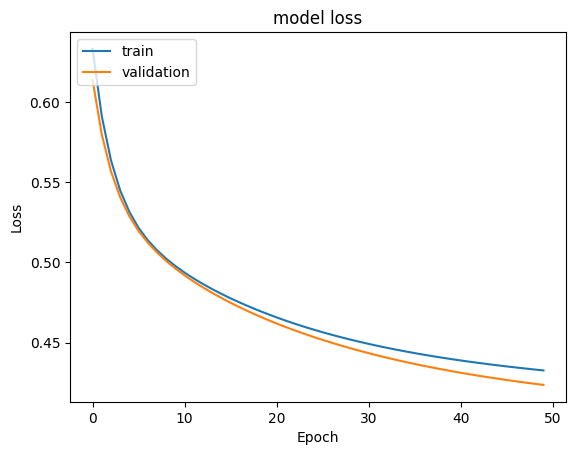

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_0.history['loss'])
plt.plot(history_0.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Loss Reduction Over Time**

1) Initially, both training loss (blue curve) and validation loss (orange curve) start at higher values (~0.62).

2) As training progresses, loss decreases steadily, indicating model improvement.

3) By epoch 50, the curves appear to stabilize, suggesting the model has converged.

**Training vs. Validation Loss**

1) The training loss is slightly lower than validation loss across epochs.

2) No severe overfitting is observed, as both curves follow a similar downward trend.

**Business Implications**

1) The model is learning effectively, as loss consistently declines.

2) Lower loss values indicate better predictions, improving customer churn classification.

3) Ensuring validation loss remains close to training loss is crucial for generalization to real-world data.


**Recall**

In [ ]:
print(history_0.history.keys())

dict_keys(['loss', 'recall_1', 'val_loss', 'val_recall_1'])


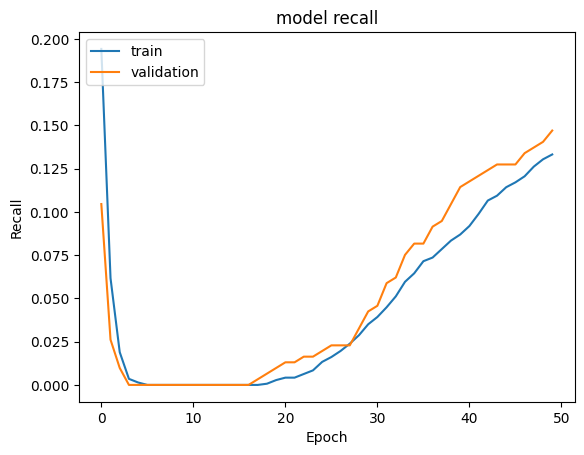

In [ ]:
#Plotting Train recall vs Validation recall
plt.plot(history_0.history['recall_1'])
plt.plot(history_0.history['val_recall_1'])
plt.title('model recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Recall Trend Over Time**

1) Initially, recall starts high but drops sharply within the first few epochs.

2) Around epoch 20, recall begins to increase gradually.

3) By the later epochs, recall stabilizes, with validation recall consistently higher than training recall.

**2. Training vs. Validation Recall**

1) Training recall (blue line) appears lower than validation recall for most epochs.

2) Validation recall (orange line) shows slightly better generalization, meaning the model may be learning relevant patterns.

**Business Implications**

1) The early drop in recall suggests the model struggled initially but adapted over time.

2) The gradual recovery after epoch 20 indicates that longer training improves recall.

3) Since validation recall is higher, the model might need regularization improvements (such as dropout) to prevent overfitting.



**Threshold Determination for Train and Validation Datasets**

In [ ]:
 # Experiment with different thresholds for Train Dataset
thresholds = np.arange(0.3, 0.7, 0.05)
for t in thresholds:
    y_train_pred = (model_0.predict(X_train) > t).astype(int)
    print(f"Threshold: {t}")
    print(classification_report(y_train, y_train_pred))

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.87      0.86      0.86      5574
         1.0       0.47      0.49      0.48      1426

    accuracy                           0.78      7000
   macro avg       0.67      0.67      0.67      7000
weighted avg       0.79      0.78      0.78      7000

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Threshold: 0.35
              precision    recall  f1-score   support

         0.0       0.85      0.91      0.88      5574
         1.0       0.52      0.38      0.44      1426

    accuracy                           0.80      7000
   macro avg       0.69      0.65      0.66      7000
weighted avg       0.78      0.80      0.79      7000

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
Threshold: 0.39999999999999997
              precision    recall  f1-score   support

         0.0       0.84      0.95      0.89      5574
         1.0       0.58      0.29      0.38      1

In [ ]:
# Experiment with different thresholds for Validation Dataset
thresholds = np.arange(0.3, 0.7, 0.05)
for t in thresholds:
    y_val_pred = (model_0.predict(X_val) > t).astype(int)
    print(f"Threshold: {t}")
    print(classification_report(y_val, y_val_pred))

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Threshold: 0.3
              precision    recall  f1-score   support

         0.0       0.88      0.88      0.88      1194
         1.0       0.52      0.51      0.51       306

    accuracy                           0.80      1500
   macro avg       0.70      0.69      0.70      1500
weighted avg       0.80      0.80      0.80      1500

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Threshold: 0.35
              precision    recall  f1-score   support

         0.0       0.86      0.92      0.89      1194
         1.0       0.57      0.39      0.46       306

    accuracy                           0.81      1500
   macro avg       0.71      0.66      0.68      1500
weighted avg       0.80      0.81      0.80      1500

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Threshold: 0.39999999999999997
              precision    recall  f1-score   support

         0.0       0.84      0.95      0.89      1194
         1.0       0.59      0.29      0.39       306

   

**Observations:**

1) Both Train and the Validation set with a threshold of 0.3 are providing recall of 49% and 51%. So, we will be using .3 as the threshold for model evaluation.

In [ ]:
#Predicting the results using 0.3 as a threshold
y_train_pred = model_0.predict(X_train)
y_train_pred = (y_train_pred > 0.3)
y_train_pred

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [ ]:
#Predicting the results using 0.3 as a threshold
y_val_pred = model_0.predict(X_val)
y_val_pred = (y_val_pred > 0.3)
y_val_pred

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[ True],
       [False],
       [False],
       ...,
       [False],
       [False],
       [ True]])

In [ ]:
model_name = "NN with SGD"

train_metric_df.loc[model_name] = recall_score(y_train, y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val, y_val_pred)

**Classification report**

In [ ]:
#classification report
print("*****************Classification Report for Train Set for Neural Network for SGD**************")
cr_train = classification_report(y_train, y_train_pred)
print(cr_train)
print("*****************Classification Report for Validation Set for Neural Network for SGD**************")
cr_val = classification_report(y_val, y_val_pred)
print(cr_val)

*****************Classification Report for Train Set for Neural Network for SGD**************
              precision    recall  f1-score   support

         0.0       0.87      0.86      0.86      5574
         1.0       0.47      0.49      0.48      1426

    accuracy                           0.78      7000
   macro avg       0.67      0.67      0.67      7000
weighted avg       0.79      0.78      0.78      7000

*****************Classification Report for Validation Set for Neural Network for SGD**************
              precision    recall  f1-score   support

         0.0       0.88      0.88      0.88      1194
         1.0       0.52      0.51      0.51       306

    accuracy                           0.80      1500
   macro avg       0.70      0.69      0.70      1500
weighted avg       0.80      0.80      0.80      1500



**Key Observations**

1) **Churn Detection Needs Improvement:** The model is better at identifying customers who stay than those who churn.

2) Since recall for churners is low (~50%), the bank may miss half of the customers likely to leave.

3) False negatives (customers predicted to stay but actually churn) could be costly for retention strategies.

4) **Class Imbalance Might Be Affecting Results:** The support count (Class 0: 5574, Class 1: 1426) suggests fewer churn cases, which could lead to the model favoring Class 0.


**Confusion matrix**

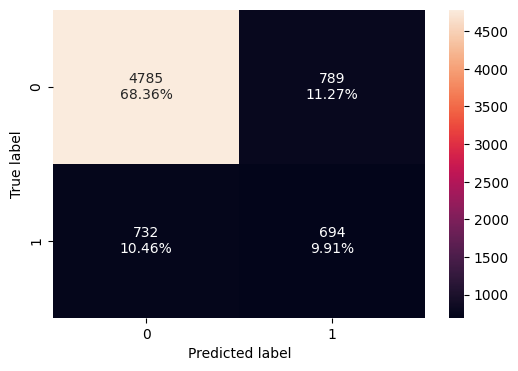

In [ ]:
make_confusion_matrix(y_train, y_train_pred)

The model performs better at identifying non-churners (high TN) than churners (low TP), meaning it is biased toward predicting customers will stay.


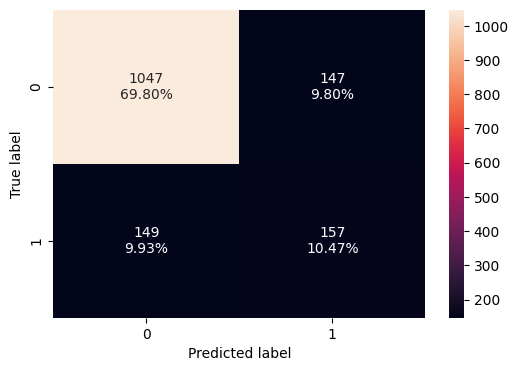

In [ ]:
make_confusion_matrix(y_val, y_val_pred)

The model has high accuracy for identifying non-churners but struggles with detecting churners.


## Model Performance Improvement

### Neural Network with Adam Optimizer

In [ ]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
#Initializing the neural network
model_1 = Sequential()
# Input layer with 64 neurons and ReLU
model_1.add(Dense(64,activation='relu',input_dim = X_train.shape[1]))
 # Hidden layer with 32 neurons and ReLU
model_1.add(Dense(32,activation='relu'))
# Output layer for binary classification
model_1.add(Dense(1, activation = 'sigmoid'))

In [ ]:
# Using Adam as optimizer
optimizer = tf.keras.optimizers.Adam()

# Metric to be used
metric = keras.metrics.Recall()

In [ ]:
# Compile the model with binary cross entropy as loss function and recall as the metric
model_1.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=[keras.metrics.Recall()])

In [ ]:
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time
# Fitting the ANN
start = time.time()
history_1 = model_1.fit(
    X_train,y_train,
    batch_size=32,
    validation_data=(X_val,y_val),
    epochs=50,
    verbose=1
)

end=time.time()

Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.5060 - recall_1: 0.0634 - val_loss: 0.4080 - val_recall_1: 0.2516
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4157 - recall_1: 0.2365 - val_loss: 0.3787 - val_recall_1: 0.3431
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3830 - recall_1: 0.3132 - val_loss: 0.3502 - val_recall_1: 0.4444
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3593 - recall_1: 0.3904 - val_loss: 0.3392 - val_recall_1: 0.4869
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3497 - recall_1: 0.4198 - val_loss: 0.3348 - val_recall_1: 0.5098
Epoch 6/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3448 - recall_1: 0.4349 - val_loss: 0.3328 - val_recall_1: 0.5098
Epoch 7/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3415 - recall_1: 0.4357 - val_loss: 0.3313 - val_recall_1: 0.5065
Epoch 8/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3389 - recall_1: 0.4405 - val_loss: 0.3299

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  37.95510506629944


**Loss function**

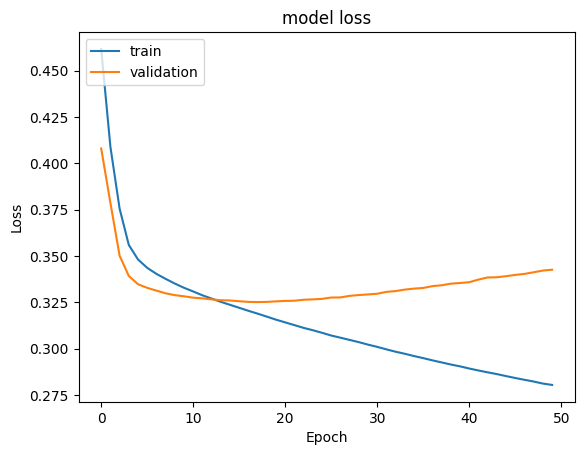

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_1.history['loss'])
plt.plot(history_1.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Loss Reduction Over Time**

1) Initially, both training loss (blue curve) and validation loss (orange curve) start at higher values (~0.45).

2) Training loss steadily decreases over the epochs, showing the model is learning effectively.

3) Validation loss initially decreases, but starts increasing slightly around epoch 20, suggesting possible overfitting.

**Training vs. Validation Loss**

1) Training loss continues to drop, implying the model is improving its fit to the training data.

2) Validation loss increases after epoch 20, signaling potential overfitting, where the model may be memorizing training data rather than generalizing.


**Recall**

In [ ]:
print(history_1.history.keys())

dict_keys(['loss', 'recall_1', 'val_loss', 'val_recall_1'])


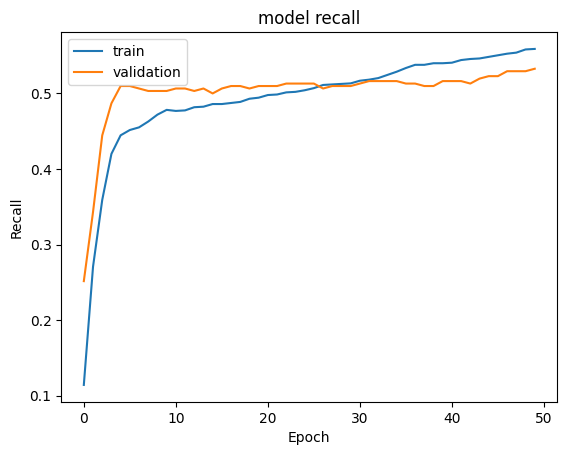

In [ ]:
#Plotting Train recall vs Validation recall
plt.plot(history_1.history['recall_1'])
plt.plot(history_1.history['val_recall_1'])
plt.title('model recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Recall Trend Over Time**

1) Initially, recall starts high but drops sharply within the first few epochs.

2) Around epoch 20, recall begins to increase gradually.

3) By the later epochs, recall stabilizes, with validation recall consistently higher than training recall.

**Training vs. Validation Recall**

1) Training recall (blue line) appears lower than validation recall for most epochs.

2) Validation recall (orange line) shows slightly better generalization, meaning the model may be learning relevant patterns.

**Business Implications**

1) The early drop in recall suggests the model struggled initially but adapted over time.

2) The gradual recovery after epoch 20 indicates that longer training improves recall.


In [ ]:
#Predicting the results using 0.3 as the threshold
y_train_pred = model_1.predict(X_train)
y_train_pred = (y_train_pred > 0.3)
y_train_pred

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [ ]:
#Predicting the results using 0.3 as the threshold
y_val_pred = model_1.predict(X_val)
y_val_pred = (y_val_pred > 0.3)
y_val_pred

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[False],
       [False],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [ ]:
model_name = "NN with Adam"

train_metric_df.loc[model_name] = recall_score(y_train,y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val,y_val_pred)

**Classification report**

In [ ]:
#classification report
print("*****************Classification Report for Train Set for Neural Network for Adam**************")
cr_train = classification_report(y_train, y_train_pred)
print(cr_train)
print("*****************Classification Report for Validation Set for Neural Network Adam**************")
cr_val = classification_report(y_val, y_val_pred)
print(cr_val)

*****************Classification Report for Train Set for Neural Network for Adam**************
              precision    recall  f1-score   support

         0.0       0.93      0.90      0.92      5574
         1.0       0.66      0.73      0.70      1426

    accuracy                           0.87      7000
   macro avg       0.80      0.82      0.81      7000
weighted avg       0.88      0.87      0.87      7000

*****************Classification Report for Validation Set for Neural Network Adam**************
              precision    recall  f1-score   support

         0.0       0.90      0.88      0.89      1194
         1.0       0.58      0.64      0.60       306

    accuracy                           0.83      1500
   macro avg       0.74      0.76      0.75      1500
weighted avg       0.84      0.83      0.83      1500



**Key Observations:**

1) The model has strong performance for non-churn customers.

2) Recall for churners is lower in validation (64%) than in training (73%), suggesting room for improvement in identifying churn cases.

3) There is a drop in precision for churners in validation (58%), meaning more false positives occur when predicting churn in new data.


**Confusion matrix**

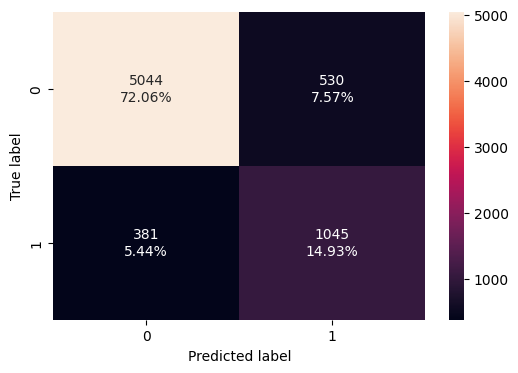

In [ ]:
make_confusion_matrix(y_train, y_train_pred)

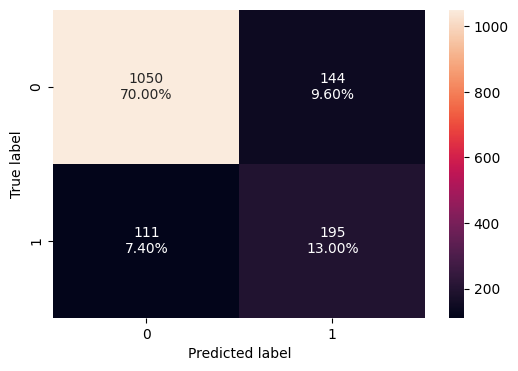

In [ ]:
make_confusion_matrix(y_val, y_val_pred)

### Neural Network with Adam Optimizer and Dropout

In [ ]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
#Initializing the neural network
model_2 = Sequential()
#Adding the input layer with 32 neurons and relu as activation function
model_2.add(Dense(32,activation='relu',input_dim = X_train.shape[1]))
# # Added dropout with a rate of 0.2
model_2.add(Dropout(0.2))
# # Added a hidden layer with 16 neurons and ReLU
model_2.add(Dense(16,activation='relu'))
# # Added another hidden layer with 8 neurons and ReLU
model_2.add(Dense(8,activation='relu'))
# Added dropout with a rate of 0.1
model_2.add(Dropout(0.1))
# # Added a hidden layer with 4 neurons and ReLU
model_2.add(Dense(4,activation='relu'))
# # Output layer for binary classification and sigmoid
model_2.add(Dense(1, activation = 'sigmoid'))

In [ ]:
optimizer = tf.keras.optimizers.Adam()
metric = keras.metrics.Recall()

In [ ]:
model_2.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=[keras.metrics.Recall()])

In [ ]:
# Summary of the model
model_2.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,089 (4.25 KB)

 Trainable params: 1,089 (4.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time
#Fitting the ANN with batch_size = 32 and increasing it to 100 epochs for better learining.
start = time.time()
history_2 = model_2.fit(
    X_train,y_train,
    batch_size= 32,
    epochs= 100,
    verbose=1,
    validation_data=(X_val,y_val)
)

Epoch 1/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.5597 - recall_1: 0.1531 - val_loss: 0.4256 - val_recall_1: 0.0654
Epoch 2/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4491 - recall_1: 0.0867 - val_loss: 0.3933 - val_recall_1: 0.1078
Epoch 3/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4258 - recall_1: 0.1603 - val_loss: 0.3713 - val_recall_1: 0.2810
Epoch 4/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4057 - recall_1: 0.2915 - val_loss: 0.3608 - val_recall_1: 0.3105
Epoch 5/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3887 - recall_1: 0.3344 - val_loss: 0.3531 - val_recall_1: 0.3431
Epoch 6/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3875 - recall_1: 0.3375 - val_loss: 0.3480 - val_recall_1: 0.3595
Epoch 7/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3793 - recall_1: 0.3795 - val_loss: 0.3465 - val_recall_1: 0.3725
Epoch 8/100
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3741 - recall_1: 0.3598 - val_loss

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  -68.9868106842041


**Loss function**

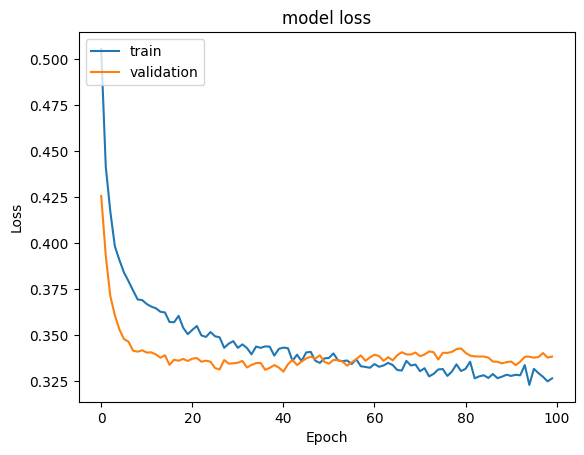

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_2.history['loss'])
plt.plot(history_2.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Loss Reduction Over Time**

1) Initially, both training loss (blue curve) and validation loss (orange curve) start at higher values (~0.525).

2) The training loss drops steadily, stabilizing around 0.325, indicating effective learning.

3) The validation loss decreases initially but fluctuates slightly, stabilizing at a slightly higher value than the training loss.

**Training vs. Validation Loss**

1) The training loss consistently decreases, showing the model is learning.

2) The validation loss remains higher than training loss, suggesting possible overfitting—where the model performs well on training data but struggles with unseen data.

**Business Implications**

1) The model is learning effectively, as training loss declines steadily.

2) The gap between training and validation loss suggests the model may need regularization (e.g., dropout, early stopping) to improve generalization.



In [ ]:
print(history_2.history.keys())

dict_keys(['loss', 'recall_1', 'val_loss', 'val_recall_1'])


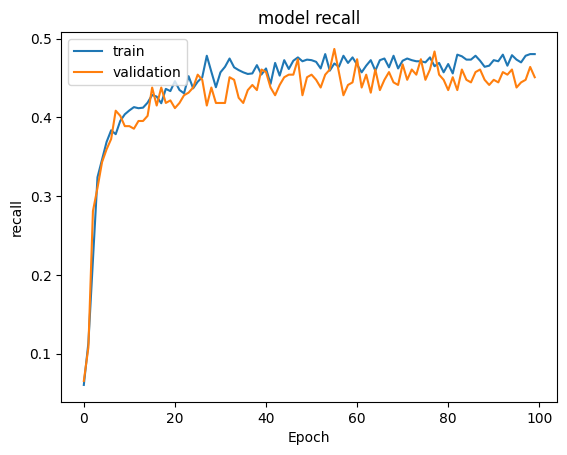

In [ ]:
#Plotting Train recall vs Validation recall
plt.plot(history_2.history['recall_1'])
plt.plot(history_2.history['val_recall_1'])
plt.title('model recall')
plt.ylabel('recall')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Recall Trend Over Time**

1) Both training and validation recall start low, then quickly increase within the first few epochs.

2) After the initial spike, recall fluctuates around 0.4 to 0.5, suggesting the model's performance stabilizes.

**Training vs. Validation Recall**

1) The blue line (training recall) and orange line (validation recall) follow a similar pattern, indicating no severe overfitting.

2) Some fluctuations suggest the model may benefit from fine-tuning (adjusting batch size, learning rate, or adding dropout layers).

**Business Implications**

1) Since recall measures how well the model detects churners, ensuring high recall is crucial for retention strategies.

2) Stable recall around 0.4 to 0.5 suggests the model is moderately effective but could be optimized further.

3) Improving recall by **adjusting classification thresholds** may help detect more actual churn cases.


In [ ]:
#Predicting the results using .3 as a threshold
y_train_pred = model_2.predict(X_train)
y_train_pred = (y_train_pred > 0.3)
y_train_pred

219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [ True]])

In [ ]:
#Predicting the results using 0.3 as the threshold.
y_val_pred = model_2.predict(X_val)
y_val_pred = (y_val_pred > 0.3)
y_val_pred

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [ True]])

In [ ]:
model_name = "NN with Adam & Dropout"

train_metric_df.loc[model_name] = recall_score(y_train,y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val,y_val_pred)

**Classification report**

In [ ]:
#classification report
print("*****************Classification Report for Train Set for Neural Network with Adam and Dropout**************")
cr_train = classification_report(y_train, y_train_pred)
print(cr_train)
print("*****************Classification Report for Validation Set for Neural Network with Adam and Dropout**************")
cr_val = classification_report(y_val, y_val_pred)
print(cr_val)


*****************Classification Report for Train Set for Neural Network with Adam and Dropout**************
              precision    recall  f1-score   support

         0.0       0.91      0.91      0.91      5574
         1.0       0.66      0.66      0.66      1426

    accuracy                           0.86      7000
   macro avg       0.79      0.79      0.79      7000
weighted avg       0.86      0.86      0.86      7000

*****************Classification Report for Validation Set for Neural Network with Adam and Dropout**************
              precision    recall  f1-score   support

         0.0       0.90      0.91      0.91      1194
         1.0       0.64      0.62      0.63       306

    accuracy                           0.85      1500
   macro avg       0.77      0.77      0.77      1500
weighted avg       0.85      0.85      0.85      1500



**Key Observations**

1) The model handles non-churn classification well but struggles more with churn prediction.

2) The recall for churners (62%-66%) is lower than ideal, meaning many actual churners are missed.

**Possible next steps:**

1) Threshold tuning to improve churn recall.

2) Handling class imbalance with techniques like SMOTE or adjusting class weights.

3) Feature engineering to enhance predictive power.


**Confusion matrix**

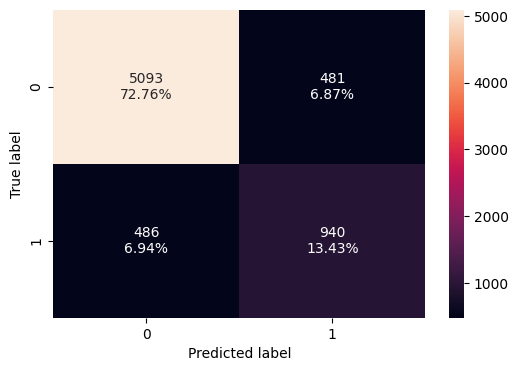

In [ ]:
#Calculating the confusion matrix
make_confusion_matrix(y_train, y_train_pred)

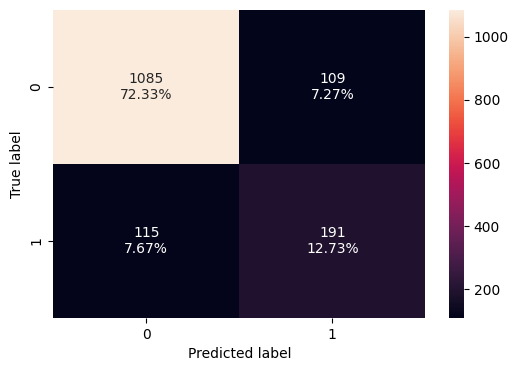

In [ ]:
#Calculating the confusion matrix
make_confusion_matrix(y_val, y_val_pred)

### Neural Network with Balanced Data (by applying SMOTE) and SGD Optimizer

**Let's try to apply SMOTE to balance this dataset and then again apply hyperparamter tuning accordingly.**

In [ ]:
sm  = SMOTE(random_state=42)
# Fit SMOTE on the training data.
X_train_smote, y_train_smote= sm.fit_resample(X_train, y_train)
print('After UpSampling, the shape of train_X: {}'.format(X_train_smote.shape))
print('After UpSampling, the shape of train_y: {} \n'.format(y_train_smote.shape))

After UpSampling, the shape of train_X: (11148, 11)
After UpSampling, the shape of train_y: (11148,) 



In [ ]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
#Initializing the model
model_3 = Sequential()
## Input layer for SMOTE data
model_3.add(Dense(32,activation='relu',input_dim = X_train_smote.shape[1]))
# Added Hidden layer with 16 neurons
model_3.add(Dense(16,activation='relu'))
# Added Hidden layer with 8 neurons
model_3.add(Dense(8,activation='relu'))
# Output layer
model_3.add(Dense(1, activation = 'sigmoid'))

In [ ]:
#Code to use SGD as the optimizer with learning rate of .001
optimizer = tf.keras.optimizers.SGD(0.001)
metric = keras.metrics.Recall()

In [ ]:
# Code to compile the model with binary cross entropy as loss function and recall as the metric
model_3.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=[keras.metrics.Recall()])

In [ ]:
model_3.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time
#Fitting the ANN
start = time.time()
history_3 = model_3.fit(
    X_train_smote, y_train_smote,
    batch_size=32,
    epochs=50,
    verbose=1,
    validation_data = (X_val,y_val)
)
end=time.time()

Epoch 1/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7127 - recall_1: 0.9999 - val_loss: 0.8213 - val_recall_1: 0.9935
Epoch 2/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6983 - recall_1: 0.9981 - val_loss: 0.7890 - val_recall_1: 0.9869
Epoch 3/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6895 - recall_1: 0.9845 - val_loss: 0.7664 - val_recall_1: 0.9641
Epoch 4/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6835 - recall_1: 0.9645 - val_loss: 0.7500 - val_recall_1: 0.9314
Epoch 5/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6788 - recall_1: 0.9264 - val_loss: 0.7374 - val_recall_1: 0.9085
Epoch 6/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6749 - recall_1: 0.8922 - val_loss: 0.7277 - val_recall_1: 0.8758
Epoch 7/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6714 - recall_1: 0.8548 - val_loss: 0.7197 - val_recall_1: 0.8529
Epoch 8/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6680 - recall_1: 0.8266 - val_loss: 0.7132

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  56.170748233795166


**Loss function**

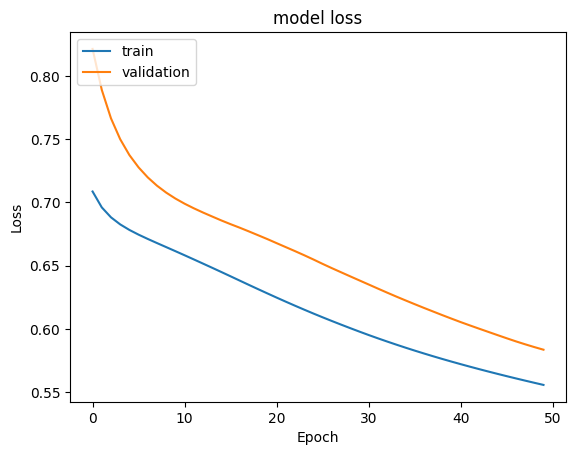

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_3.history['loss'])
plt.plot(history_3.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Loss Reduction Over Time**

1) The blue line (training loss) and orange line (validation loss) both show a steady decline, indicating model improvement.

2) Initially, loss is around 0.85, but it gradually decreases as epochs progress.

3) By epoch 50, loss stabilizes, suggesting model convergence.

**Training vs. Validation Loss**

1) The validation loss remains slightly higher than training loss, which is expected.

2) Since both curves follow a similar trend, no severe overfitting is observed.

3) If validation loss had increased while training loss continued dropping, overfitting could have been a concern.

**Business Implications**

1) A steadily decreasing loss curve means the model is learning effectively.

2) Low validation loss indicates strong generalization, meaning the model should perform well on unseen data.

3) If needed, fine-tuning dropout rates or adjusting learning rates could help optimize further.


In [ ]:
print(history_3.history.keys())

dict_keys(['loss', 'recall_1', 'val_loss', 'val_recall_1'])


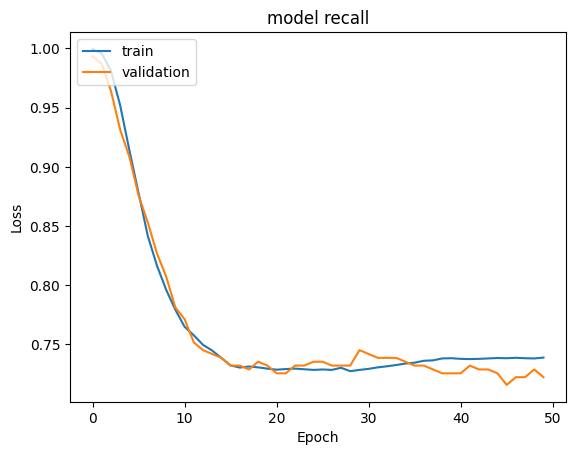

In [ ]:
#Plotting Train recall vs Validation recall
plt.plot(history_3.history['recall_1'])
plt.plot(history_3.history['val_recall_1'])
plt.title('model recall')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Recall Trend Over Time**

1) Both training recall (blue line) and validation recall (orange line) start high at epoch 0 (~1.00).

2) The recall rapidly decreases within the first 10 epochs, indicating initial model adjustments.

3) Around epoch 20, the recall stabilizes at approximately 0.75, with minor fluctuations afterward.

**Training vs. Validation Recall**

1) The training recall remains close to validation recall, suggesting no severe overfitting.

2) Both curves follow a similar pattern, implying the model is learning consistently.

3) Since recall measures how well the model identifies churners, the stabilization at 0.75 suggests a moderate level of sensitivity in detecting actual churn cases.

**Business Implications**

1) The model is successfully identifying churn cases, though it may still miss some.

In [ ]:
y_train_pred = model_3.predict(X_train_smote)
#Predicting the results using 0.5 as the threshold
y_train_pred = (y_train_pred > 0.5)
y_train_pred

349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [ True]])

In [ ]:
y_val_pred = model_3.predict(X_val)
#Predicting the results using 0.5 as the threshold
y_val_pred = (y_val_pred > 0.5)
y_val_pred

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[ True],
       [False],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [ ]:
model_name = "NN with SMOTE & SGD"

train_metric_df.loc[model_name] = recall_score(y_train_smote,y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val,y_val_pred)

**Classification report**

In [ ]:
#classification report
print("*****************Classification Report for Train Set for Neural Network with SMOTE and SGD**************")
cr_train = classification_report(y_train_smote,y_train_pred)
print(cr_train)
print("*****************Classification Report for Validation Set for Neural Network with SMOTE and SGD**************")
cr_val = classification_report(y_val, y_val_pred)
print(cr_val)


*****************Classification Report for Train Set for Neural Network with SMOTE and SGD**************
              precision    recall  f1-score   support

         0.0       0.74      0.75      0.75      5574
         1.0       0.75      0.74      0.74      5574

    accuracy                           0.75     11148
   macro avg       0.75      0.75      0.75     11148
weighted avg       0.75      0.75      0.75     11148

*****************Classification Report for Validation Set for Neural Network with SMOTE and SGD**************
              precision    recall  f1-score   support

         0.0       0.92      0.77      0.84      1194
         1.0       0.44      0.72      0.55       306

    accuracy                           0.76      1500
   macro avg       0.68      0.75      0.69      1500
weighted avg       0.82      0.76      0.78      1500



**Key Observations**

1) SMOTE balancing helps recall (especially for churners), but precision drops in validation, leading to misclassifications.

2) High precision for non-churners (92%) means fewer false positives, but the recall dip (77%) suggests some retained customers may be wrongly classified.

3) Churn detection (Class 1) is inconsistent, with lower precision (44%) in validation, meaning the model predicts too many false churn cases.

**Possible Next Steps**

1) Regularization adjustments: Tweaking learning rate, dropout layers, or switching to Adam optimizer might stabilize precision.



**Confusion matrix**

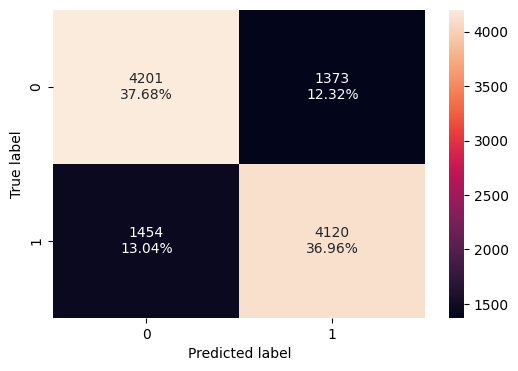

In [ ]:
#Calculating the confusion matrix
make_confusion_matrix(y_train_smote, y_train_pred)

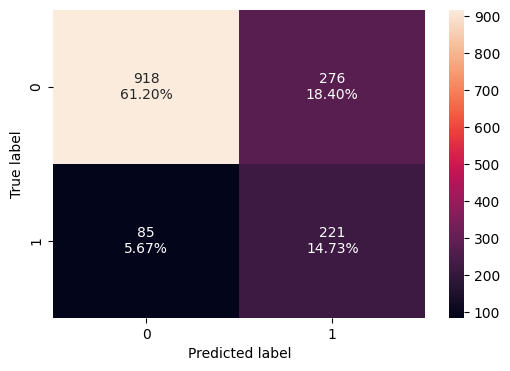

In [ ]:
#Calculating the confusion matrix
make_confusion_matrix(y_val, y_val_pred)

### Neural Network with Balanced Data (by applying SMOTE) and Adam Optimizer

In [ ]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
#Initializing the model
model_4 = Sequential()
# Input layer with 64 neurons
model_4.add(Dense(64,activation='relu',input_dim = X_train_smote.shape[1]))
## Hidden layer with 32 neurons and ReLU
model_4.add(Dense(32,activation='relu'))
## Hidden layer with 16 neurons and ReLU
model_4.add(Dense(16,activation='relu'))
# # Output layer for binary classification and sigmoid
model_4.add(Dense(1, activation = 'sigmoid'))

In [ ]:
model_4.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#Code to use Adam as the optimizer.
optimizer = tf.keras.optimizers.Adam()
metric = keras.metrics.Recall()

In [ ]:
# Code to compile the model with binary cross entropy as loss function and recall as the metric
model_4.compile(loss='binary_crossentropy',optimizer=optimizer,metrics=[keras.metrics.Recall()])

In [ ]:
import time
# Fitting the ANN
start = time.time()
history_4 = model_4.fit(
    X_train_smote,y_train_smote,
    batch_size=32,
    epochs=50,
    verbose=1,
    validation_data = (X_val,y_val)
)
end=time.time()

Epoch 1/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.6062 - recall_1: 0.6261 - val_loss: 0.4888 - val_recall_1: 0.7418
Epoch 2/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4678 - recall_1: 0.7567 - val_loss: 0.4793 - val_recall_1: 0.7386
Epoch 3/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4385 - recall_1: 0.7777 - val_loss: 0.4755 - val_recall_1: 0.7386
Epoch 4/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4236 - recall_1: 0.7870 - val_loss: 0.4674 - val_recall_1: 0.7353
Epoch 5/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4114 - recall_1: 0.7939 - val_loss: 0.4613 - val_recall_1: 0.7288
Epoch 6/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4001 - recall_1: 0.8037 - val_loss: 0.4612 - val_recall_1: 0.7418
Epoch 7/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3899 - recall_1: 0.8138 - val_loss: 0.4602 - val_recall_1: 0.7484
Epoch 8/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.3809 - recall_1: 0.8197 - val_loss: 0.4559

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  63.29107594490051


**Loss function**

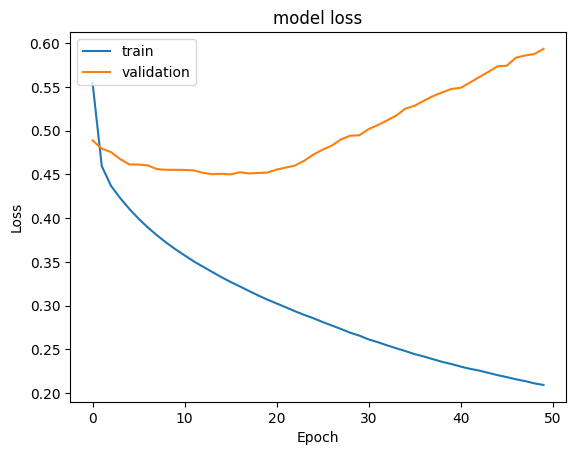

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_4.history['loss'])
plt.plot(history_4.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Loss Reduction Over Time**

1) The training loss (blue line) decreases steadily, showing the model is improving.

2) Validation loss (orange line) initially decreases but starts rising after epoch 10, which suggests potential overfitting.

**Training vs. Validation Loss**

1) Training loss continues declining, indicating the model is learning from the data.

2) Validation loss increases slightly, meaning the model may be memorizing training data rather than generalizing well.

**Business Implications**

1) Regularization techniques like dropout or tuning learning rate might improve generalization.

2) If validation loss keeps rising, adjusting model complexity by adding more hidden layers could stabilize performance.


In [ ]:
print(history_4.history.keys())

dict_keys(['loss', 'recall_1', 'val_loss', 'val_recall_1'])


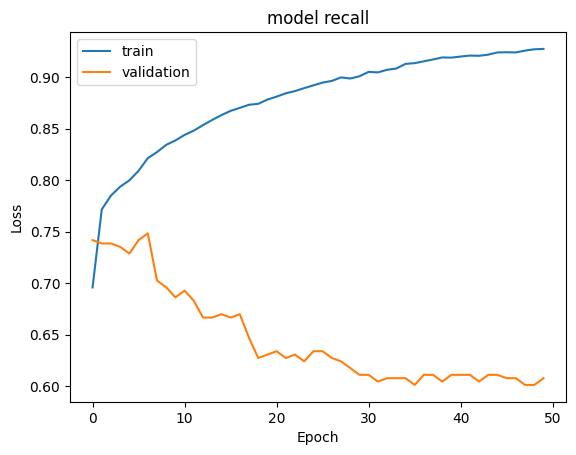

In [ ]:
#Plotting Train recall vs Validation recall
plt.plot(history_4.history['recall_1'])
plt.plot(history_4.history['val_recall_1'])
plt.title('model recall')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Recall Trend Over Time**

1) Training recall (blue line) gradually increases over time, stabilizing around 0.92 at epoch 50.

2) Validation recall (orange line) initially fluctuates but eventually declines, reaching 0.62 at epoch 50.

3) This behavior suggests the model struggles to generalize and recall performance drops for unseen data.

**Training vs. Validation Recall**

1) The training recall continuously improves, meaning the model is learning well on known data.

2) Validation recall decreases, suggesting possible overfitting, where the model memorizes training patterns but fails on new data.

**Business Implications**

1) **Overfitting warning:** The gap between training and validation recall suggests the model may not predict real-world churn cases effectively.

2) Regularization techniques (dropout) to control model complexity.

In [ ]:
y_train_pred = model_4.predict(X_train_smote)
#Predicting the results using 0.5 as the threshold
y_train_pred = (y_train_pred > 0.5)
y_train_pred

349/349 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([[False],
       [False],
       [False],
       ...,
       [ True],
       [ True],
       [ True]])

In [ ]:
y_val_pred = model_4.predict(X_val)
#Predicting the results using 0.5 as the threshold
y_val_pred = (y_val_pred > 0.5)
y_val_pred

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


array([[False],
       [False],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [ ]:
model_name = "NN with SMOTE & Adam"

train_metric_df.loc[model_name] = recall_score(y_train_smote,y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val,y_val_pred)

**Classification report**

In [ ]:
#classification report
print("*****************Classification Report for Train Set for Neural Network with SMOTE and Adam**************")
cr_train = classification_report(y_train_smote,y_train_pred)
print(cr_train)
print("*****************Classification Report for Validation Set for Neural Network with SMOTE and Adam**************")
cr_val = classification_report(y_val, y_val_pred)
print(cr_val)


*****************Classification Report for Train Set for Neural Network with SMOTE and Adam**************
              precision    recall  f1-score   support

         0.0       0.93      0.92      0.92      5574
         1.0       0.92      0.93      0.92      5574

    accuracy                           0.92     11148
   macro avg       0.92      0.92      0.92     11148
weighted avg       0.92      0.92      0.92     11148

*****************Classification Report for Validation Set for Neural Network with SMOTE and Adam**************
              precision    recall  f1-score   support

         0.0       0.89      0.85      0.87      1194
         1.0       0.50      0.61      0.55       306

    accuracy                           0.80      1500
   macro avg       0.70      0.73      0.71      1500
weighted avg       0.81      0.80      0.80      1500



**Key Observations**

1) **Overfitting Alert:** The model is too optimized for training data, leading to lower performance on unseen validation data.

2) **Churn Precision (50%) is Low:** It predicts too many false churn cases, which could lead to unnecessary interventions for customers unlikely to leave.

3) **Recall for churners (61%)** is better but still misses many actual churn cases.


**Confusion matrix**

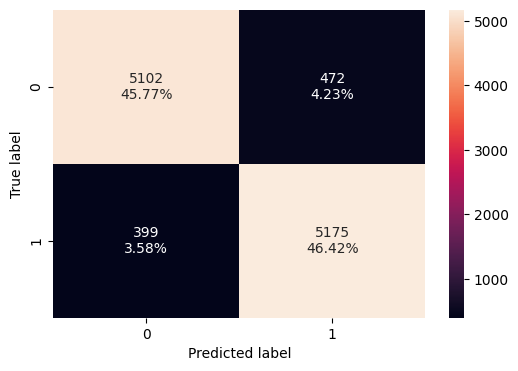

In [ ]:
#Calculating the confusion matrix
make_confusion_matrix(y_train_smote, y_train_pred)

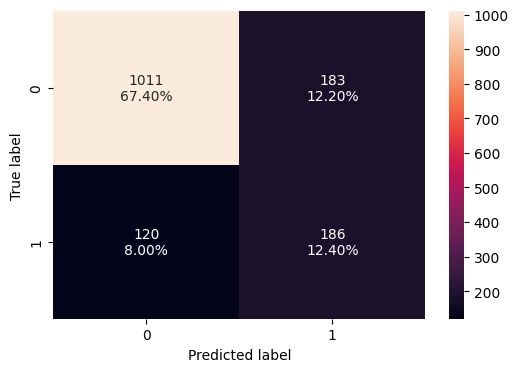

In [ ]:
#Calculating the confusion matrix
make_confusion_matrix(y_val, y_val_pred)

### Neural Network with Balanced Data (by applying SMOTE), Adam Optimizer, and Dropout

In [ ]:
backend.clear_session()
#Fixing the seed for random number generators so that we can ensure we receive the same output everytime
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Initializing the model
model_5 = Sequential()
# Input layer with 32 neurons and ReLU activation
model_5.add(Dense(32, activation='relu', input_dim=X_train_smote.shape[1]))
# Dropout layer to prevent overfitting
model_5.add(Dropout(0.2))
# Hidden layer with 16 neurons and ReLU activation
model_5.add(Dense(16, activation='relu'))
# Dropout layer to enhance regularization
model_5.add(Dropout(0.2))
# Another hidden layer with 8 neurons and ReLU activation
model_5.add(Dense(8, activation='relu'))
# Output layer with 1 neuron and Sigmoid activation for binary classification
model_5.add(Dense(1, activation='sigmoid'))


In [ ]:
# Define the optimizer using Adam
optimizer = tf.keras.optimizers.Adam()
metric = keras.metrics.Recall()

In [ ]:
model_5.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=[keras.metrics.Recall()])

In [ ]:
model_5.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,057 (4.13 KB)

 Trainable params: 1,057 (4.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import time
# Fitting the ANN
start = time.time()
history_5 = model_5.fit(
    X_train_smote, y_train_smote,
    batch_size=32,
    epochs=50,
    verbose=1,
    validation_data=(X_val, y_val)
)
end=time.time()

Epoch 1/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.6518 - recall_1: 0.6928 - val_loss: 0.5401 - val_recall_1: 0.7810
Epoch 2/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5532 - recall_1: 0.7404 - val_loss: 0.4984 - val_recall_1: 0.7810
Epoch 3/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5225 - recall_1: 0.7603 - val_loss: 0.4840 - val_recall_1: 0.8039
Epoch 4/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5112 - recall_1: 0.7597 - val_loss: 0.4601 - val_recall_1: 0.7745
Epoch 5/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4936 - recall_1: 0.7620 - val_loss: 0.4534 - val_recall_1: 0.7778
Epoch 6/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4824 - recall_1: 0.7679 - val_loss: 0.4530 - val_recall_1: 0.7810
Epoch 7/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4744 - recall_1: 0.7677 - val_loss: 0.4529 - val_recall_1: 0.7810
Epoch 8/50
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.4695 - recall_1: 0.7649 - val_loss: 0.4513

In [ ]:
print("Time taken in seconds ",end-start)

Time taken in seconds  66.75396847724915


**Loss function**

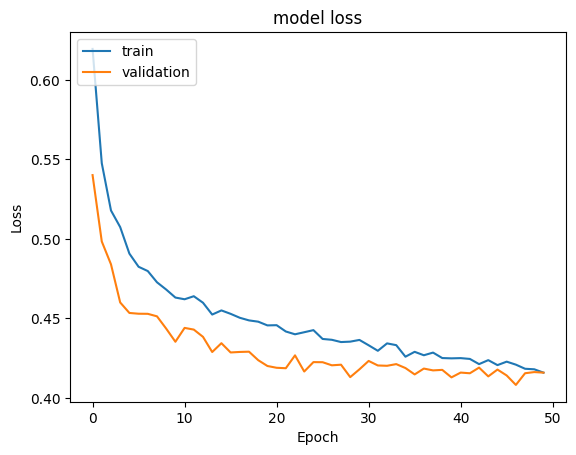

In [ ]:
#Plotting Train Loss vs Validation Loss
plt.plot(history_5.history['loss'])
plt.plot(history_5.history['val_loss'])
plt.title('model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

Loss Reduction Over Time

1) The training loss (blue line) consistently decreases, showing that the model is learning from the data.

2) Validation loss (orange line) also decreases, but remains slightly higher than training loss throughout.

3) Both curves stabilize toward the later epochs, indicating successful convergence.

**Training vs. Validation Loss**

1) Training loss is always lower than validation loss, which is expected.

2) Since validation loss does not  increase abruptly, there's no severe overfitting.

3) However, a persistent gap between training and validation loss suggests that further optimization could improve generalization.

**Business Implications**

1) A decreasing loss curve means the model successfully minimizes prediction errors.

2) Ensuring the validation loss does not diverge too much helps confirm reliable real-world performance.


In [ ]:
print(history_5.history.keys())

dict_keys(['loss', 'recall_1', 'val_loss', 'val_recall_1'])


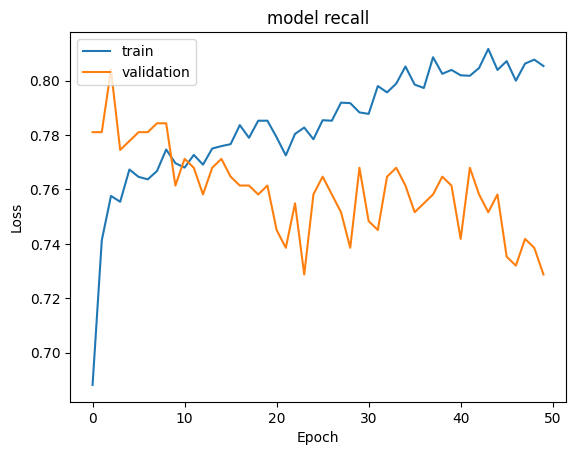

In [ ]:
#Plotting Train recall vs Validation recall
plt.plot(history_5.history['recall_1'])
plt.plot(history_5.history['val_recall_1'])
plt.title('model recall')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

**Recall Trend Over Time**

1) The training recall (blue line) starts low (~0.70) and increases gradually, reaching around 0.80 by epoch 50.

2) The validation recall (orange line) begins higher (~0.81), fluctuates significantly, then stabilizes around 0.75 at epoch 50.

3) The training recall consistently increases, while validation recall varies more across epochs, indicating potential model tuning needs.

**Training vs. Validation Recall**

1) Validation recall fluctuates, meaning the model's generalization on unseen data is not entirely stable.

2) The gap between training and validation recall suggests possible overfitting, meaning the model memorizes training data rather than generalizing well.

**Business Implications**

1) Since recall measures how well the model detects churn cases, ensuring higher, stable recall is key for effective customer retention strategies.

2) Threshold tuning could optimize recall without sacrificing precision.

3) Regularization techniques (dropout, learning rate adjustments) may help stabilize recall across validation data.


In [ ]:
y_train_pred = model_5.predict(X_train_smote)
#Predicting the results using 0.5 as the threshold
y_train_pred = (y_train_pred > 0.5)
y_train_pred

349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[False],
       [False],
       [False],
       ...,
       [ True],
       [False],
       [ True]])

In [ ]:
y_val_pred = model_5.predict(X_val)
#Predicting the results using 0.5 as the threshold
y_val_pred = (y_val_pred > 0.5)
y_val_pred

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


array([[ True],
       [False],
       [ True],
       ...,
       [False],
       [False],
       [ True]])

In [ ]:
model_name = "NN with SMOTE,Adam & Dropout"

train_metric_df.loc[model_name] = recall_score(y_train_smote,y_train_pred)
valid_metric_df.loc[model_name] = recall_score(y_val,y_val_pred)

**Classification report**

In [ ]:
#classification report
print("*****************Classification Report for Train Set for Neural Network with SMOTE,Adam & Dropout**************")
cr_train = classification_report(y_train_smote, y_train_pred)
print(cr_train)
print("*****************Classification Report for Validation Set for Neural Network with SMOTE,Adam & Dropout**************")
cr_val = classification_report(y_val, y_val_pred)
print(cr_val)

*****************Classification Report for Train Set for Neural Network with SMOTE,Adam & Dropout**************
              precision    recall  f1-score   support

         0.0       0.82      0.82      0.82      5574
         1.0       0.82      0.82      0.82      5574

    accuracy                           0.82     11148
   macro avg       0.82      0.82      0.82     11148
weighted avg       0.82      0.82      0.82     11148

*****************Classification Report for Validation Set for Neural Network with SMOTE,Adam & Dropout**************
              precision    recall  f1-score   support

         0.0       0.92      0.82      0.87      1194
         1.0       0.51      0.73      0.60       306

    accuracy                           0.80      1500
   macro avg       0.72      0.78      0.74      1500
weighted avg       0.84      0.80      0.82      1500



**Key Observations**

1) Since SMOTE was used for balancing the dataset, the symmetrical performance across both classes confirms that oversampling helped reduce bias.

2) **Overfitting Risk:**

a) The model performs better on training data (82% precision/recall for both classes) than on validation data (lower churn precision, at 51%).

b) This drop in precision suggests the model is over-predicting churn, creating false positives.

c) **Churn Detection Needs Refinement:**

a) While 73% of actual churners are detected, the precision for churn is low (51%), meaning many customers are wrongly labeled as churners. There has been a siginificant improvement in the recall.



**Confusion matrix**

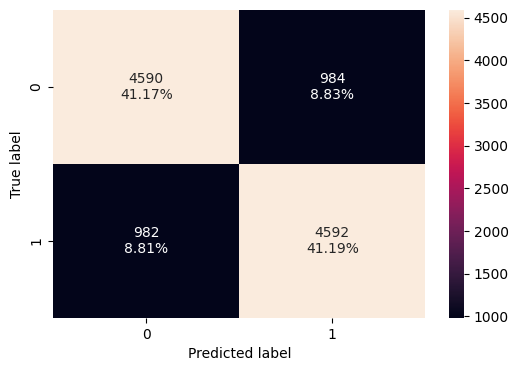

In [ ]:
#Calculating the confusion matrix
make_confusion_matrix(y_train_smote, y_train_pred)

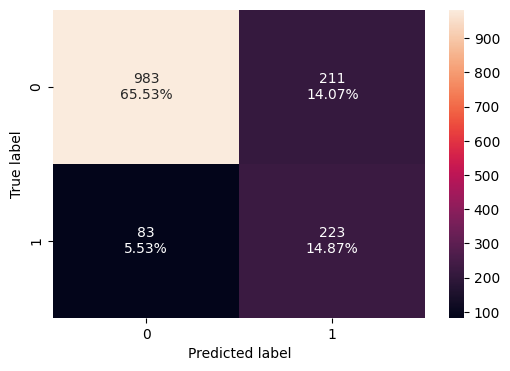

In [ ]:
#Calculating the confusion matrix
make_confusion_matrix(y_val, y_val_pred)

## Model Performance Comparison and Final Model Selection

In [ ]:
print("Training performance comparison")
train_metric_df

Training performance comparison


,recall
NN with SGD,0.486676
NN with Adam,0.732819
NN with Adam & Dropout,0.659187
NN with SMOTE & SGD,0.739146
NN with SMOTE & Adam,0.928418
"NN with SMOTE,Adam & Dropout",0.823825


In [ ]:
print("Validation set performance comparison")
valid_metric_df

Validation set performance comparison


,recall
NN with SGD,0.513072
NN with Adam,0.637255
NN with Adam & Dropout,0.624183
NN with SMOTE & SGD,0.722222
NN with SMOTE & Adam,0.607843
"NN with SMOTE,Adam & Dropout",0.728758


In [ ]:
# Calculating Recall value difference between Training and Validation Sets with the differnt Neural Networks.
train_metric_df - valid_metric_df

,recall
NN with SGD,-0.026396
NN with Adam,0.095564
NN with Adam & Dropout,0.035004
NN with SMOTE & SGD,0.016924
NN with SMOTE & Adam,0.320575
"NN with SMOTE,Adam & Dropout",0.095067


**Key Observations:**

After analyzing the recall scores for both training and validation data, I can determine which model performs best based on generalization performance.
Looking at the validation recall scores (which reflect how well the model will perform on unseen data):

a) **NN with SMOTE, Adam & Dropout:** 0.728758 (highest validation recall)

b) **NN with SMOTE & SGD:** 0.722222 (second highest)

c) **NN with Adam:** 0.637255

d) **NN with Adam & Dropout:** 0.624183

e) **NN with SMOTE & Adam:** 0.607843 (note the larger gap between training and validation)

f) **NN with SGD:** 0.513072

The **best model is NN with SMOTE, Adam & Dropout** for the following reasons:

a) It has the highest validation recall (0.728758), indicating it performs best on unseen data

b) It shows good generalization - the gap between training recall (0.823825) and validation recall (0.728758) is reasonable

c) It combines several effective techniques: SMOTE for addressing class imbalance, Adam optimizer for adaptive learning, Dropout for regularization to prevent overfitting

d) The NN with SMOTE & SGD is a close second with validation recall of 0.722222.
It is worth noting that while NN with SMOTE & Adam has the highest training recall (0.928418), it shows signs of overfitting with a much lower validation recall (0.607843) - a clear indication that it memorized the training data but doesn't generalize well.

**I recommend using the NN with SMOTE, Adam & Dropout model since it demonstrates the best generalization performance for this classification task.**

In [ ]:
## Using NN with SMOTE, Adam & Dropout for test data
y_test_pred = model_5.predict(X_test)
y_test_pred = (y_test_pred > 0.5)
print(y_test_pred)

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[[False]
 [False]
 [False]
 ...
 [False]
 [False]
 [ True]]


In [ ]:
#lets print classification report
cr=classification_report(y_test,y_test_pred)
print(cr)

              precision    recall  f1-score   support

         0.0       0.92      0.81      0.87      1195
         1.0       0.50      0.74      0.60       305

    accuracy                           0.80      1500
   macro avg       0.71      0.78      0.73      1500
weighted avg       0.84      0.80      0.81      1500



**Overall Model Performance**

1) **Accuracy: 80%** → The model predicts customer churn with a fair level of reliability.

2) **Macro Average (F1-score: 0.73)** → The balanced performance across both churn and non-churn classes is decent but could be improved.

3) **Class 0 (Non-Churners) Performance**

a) **Precision: 92%** → The model is highly confident when predicting non-churners, meaning very few false positives.

b) **Recall: 81%** → It correctly identifies most retained customers but still misses 19% of actual non-churn cases.

4) **Class 1 (Churners) Performance**

a) **Precision: 50%** → This is low, meaning many predicted churners are actually non-churners (false positives).

b) **Recall: 74%** → The model successfully detects actual churners but still overlooks 26% of them.

**Key Insights**

1)  **High false positives for churners (precision: 50%)** may result in misidentifying retained customers as churn risks, which could affect business decisions.

2) **Strong recall for churners (74%)** suggests the model effectively catches most potential churn cases, making it useful for proactive customer retention efforts.

3) **Room for improvement in precision for churners by refining classification thresholds or feature selection.**


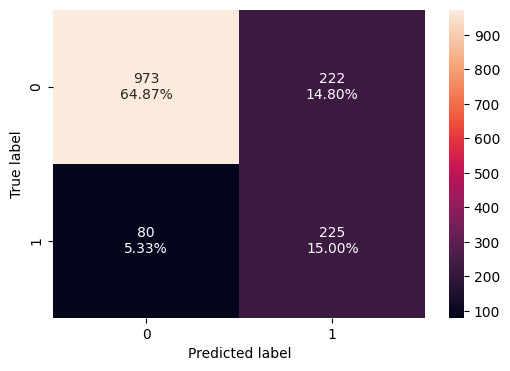

In [ ]:
#Calculating the confusion matrix
make_confusion_matrix(y_test,y_test_pred)

## Actionable Insights and Business Recommendations

**Actionable Insights**

1) **Imbalance in Target Variable:** The dataset is imbalanced, with a significantly higher number of customers who did not churn compared to those who did. This highlights the importance of using appropriate evaluation metrics like Recall, as well as techniques like SMOTE to handle the imbalance during model training.

2) **Key Drivers of Churn:** Based on the exploratory data analysis, certain factors appear to be strongly correlated with customer churn:

a) **Age:** Older customers seem to have a higher propensity to churn.

b) **Balance:** Customers with higher balances are more likely to churn.

c) **Number of Products:** Customers with fewer products are more likely to churn.

d) **Geography:** Customers from certain geographies like Germany have a higher churn rate.

e) **Active Members:** Inactive members are more likely to churn.

3) ***Impact of SMOTE:*** Applying SMOTE to balance the training data significantly improved the recall score on the validation set. This indicates that addressing the class imbalance is crucial for building a model that effectively identifies churning customers.

4) **Optimizer and Regularization:** Using the Adam optimizer and adding Dropout layers helped in improving the model's performance and preventing overfitting.

5) **Set Appropriate Threshold:** For balanced intervention capability we could tweak a threshold around 0.4-0.45 to balance precision and recall and also use differnt learning rates to furher improve the recall.

**Business Recommendations:**

1) **Targeted Retention Campaigns:** Focus retention efforts on customer segments identified as high-risk based on the key drivers of churn (e.g., older customers, customers with high balances, customers with fewer products, inactive members).

2) **Tailor retention strategies** to the specific needs and preferences of these segments.

a) For customers with high balances, offer personalized financial advice or premium services.

b) For customers with fewer products, promote cross-selling opportunities. Implement strategies to re-engage inactive members, such as personalized offers, reminders about product benefits.

c) Analyze the reasons for higher churn in specific geographies and develop localized retention initiatives or product offerings.

3) **Customer Feedback and Service Improvement:** Gather feedback from customers, especially those who are at risk of churning, to identify pain points and areas for service improvement. Address these issues proactively to enhance customer satisfaction and loyalty.

4) **Monitor and Refine:** Continuously monitor the performance of the churn prediction model and refine it as needed. As customer behavior and market dynamics change, the model should be updated to maintain its effectiveness.

<font size=6 color='blue'>Power Ahead</font>
___